# 🧠 Parkinson's Disease Detection & Severity Assessment
## Complete Two-Stage Deep Learning Pipeline

---

### Project Summary
| | Stage 1 | Stage 2 |
|---|---|---|
| **Question** | Does this person have PD? | How severe is their PD? |
| **Dataset** | MDVR-KCL + UCI Basic | UCI Telemonitoring |
| **Classical models** | Logistic · SVM · RF · XGBoost | Linear · Ridge · RF · XGBoost |
| **Deep learning** | MLP · CNN1D · CNN-BiLSTM · Transformer | Multi-Task MLP · GRU · LSTM · BiLSTM |
| **Output** | PD / Healthy + confidence | UPDRS score → Mild/Moderate/Severe |

---

### Datasets — Add all 3 to Kaggle sidebar before running
| Dataset | Path after upload |
|---|---|
| MDVR-KCL (nutansingh) | `/kaggle/input/datasets/nutansingh/mdvr-kcl-dataset` |
| UCI Basic | `/kaggle/input/datasets/gloriaabby/oxford-parkinsons-disease-detection-dataset/parkinsons.data` |
| UCI Telemonitoring | `/kaggle/input/datasets/gloriaabby/parkinsons-telemonitoring-dataset/parkinsons_updrs.csv` |

**Accelerator:** Settings → GPU T4  
**Run order:** Cell 1 → 2 → 3 → ... in sequence. After any restart run Cell 2 first.


## 🔎 Cell 1 — Diagnostic: Confirm All Files Are Found
> Run this first. Never skip it on a new session.

In [1]:
import os, glob

print('=== All files in /kaggle/input ===')
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(' ', os.path.join(root, f))


=== All files in /kaggle/input ===
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID13_pd_3_2_2.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID18_pd_4_3_3.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID34_pd_2_0_0.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID16_pd_2_0_0.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID06_pd_3_1_1.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID32_pd_3_1_1.wav
  /kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID07_pd_2_0_0.wav

## 📦 Cell 2 — Imports, Paths & Resume Check
> **Run this every session restart.** It loads all saved work automatically.

In [2]:
# ── Installations ─────────────────────────────────────────────────────────
!pip install -q librosa imbalanced-learn shap lightgbm xgboost

# ── Core imports ──────────────────────────────────────────────────────────
import os, glob, random, warnings, logging
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

# ── Audio ─────────────────────────────────────────────────────────────────
import librosa
import librosa.display
from IPython.display import Audio, display

# ── Sklearn ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.over_sampling import SMOTE

# ── Deep Learning ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import shap

# ── Silence all warnings ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
tf.get_logger().setLevel('ERROR')
logging.getLogger('librosa').setLevel(logging.ERROR)
logging.getLogger('numba').setLevel(logging.ERROR)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#2563eb', '#dc2626']

# ── Working directory ─────────────────────────────────────────────────────
os.makedirs('/kaggle/working', exist_ok=True)
WORK = '/kaggle/working'

# ══════════════════════════════════════════════════════════════════════════
# DATASET PATHS — confirmed from Cell 1 diagnostic
# ══════════════════════════════════════════════════════════════════════════
MDVR_BASE      = '/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)'
UCI_BASIC_PATH = '/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (2)/parkinsons.data'
UCI_TELE_PATH  = '/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (2)/telemonitoring/parkinsons_updrs.data'

# ── Audio constants ───────────────────────────────────────────────────────
SR          = 22050   # sample rate — captures all voice frequencies
DURATION    = 2.0     # 2-second segments — captures full tremor cycle
HOP_SEC     = 1.0     # 50% overlap — no voice event missed
N_MFCC      = 13      # standard speech analysis default
SEGMENT_LEN = int(SR * DURATION)
HOP_LEN_SEG = int(SR * HOP_SEC)

# ── Feature names — 47 features per MDVR-KCL segment ────────────────────
MDVR_FEAT_NAMES = (
    [f'MFCC_{i+1}'    for i in range(N_MFCC)] +
    [f'MFCC_d_{i+1}'  for i in range(N_MFCC)] +
    [f'MFCC_dd_{i+1}' for i in range(N_MFCC)] +
    ['Chroma','Spec_Centroid','Spec_BW','Spec_Rolloff',
     'ZCR','RMS','F0_mean','F0_std']
)
N_MDVR_FEAT = len(MDVR_FEAT_NAMES)  # 47

# ── Shared feature indices between MDVR and UCI Basic ────────────────────
# Instead of zero-padding, we use 11 conceptually equivalent features
# This prevents the model from learning dataset source instead of PD
SHARED_FEAT_NAMES = [
    'F0_mean','F0_std','ZCR','RMS',
    'MFCC_1','MFCC_2','MFCC_3','MFCC_4',
    'Chroma','Spec_Centroid','Spec_BW'
]
SHARED_IDX = [MDVR_FEAT_NAMES.index(f) for f in SHARED_FEAT_NAMES]
N_SHARED   = len(SHARED_IDX)  # 11

# UCI Basic columns that conceptually match the shared MDVR features
UCI_SHARED_COLS = [
    'MDVP:Fo(Hz)',     # ≈ F0_mean
    'MDVP:Fhi(Hz)',    # ≈ F0_std
    'NHR',             # ≈ ZCR (noise)
    'HNR',             # ≈ RMS (amplitude)
    'RPDE',            # ≈ MFCC_1 (complexity)
    'DFA',             # ≈ MFCC_2 (fractal)
    'PPE',             # ≈ MFCC_3 (pitch entropy)
    'MDVP:Jitter(%)',  # ≈ MFCC_4 (variation)
    'MDVP:Shimmer',    # ≈ Chroma (amplitude)
    'spread1',         # ≈ Spec_Centroid
    'spread2',         # ≈ Spec_BW
]

# ══════════════════════════════════════════════════════════════════════════
# ALL SAVE PATHS — every model and array saved here
# ══════════════════════════════════════════════════════════════════════════
# Stage 1
DF_FILES_PATH    = f'{WORK}/df_files.csv'
MDVR_FEAT_PATH   = f'{WORK}/mdvr_features.npz'
S1_ARRAYS_PATH   = f'{WORK}/s1_arrays.npz'
S1_SCALER_PATH   = f'{WORK}/s1_scaler.pkl'
S1_LR_PATH       = f'{WORK}/s1_lr.pkl'
S1_SVM_PATH      = f'{WORK}/s1_svm.pkl'
S1_RF_PATH       = f'{WORK}/s1_rf.pkl'
S1_XGB_PATH      = f'{WORK}/s1_xgb.pkl'
S1_MLP_PATH      = f'{WORK}/s1_mlp.keras'
S1_CNN_PATH      = f'{WORK}/s1_cnn.keras'
S1_CNNLSTM_PATH  = f'{WORK}/s1_cnnlstm.keras'
S1_TRANS_PATH    = f'{WORK}/s1_transformer.keras'
# Stage 2
S2_ARRAYS_PATH   = f'{WORK}/s2_arrays.npz'
S2_SCALER_PATH   = f'{WORK}/s2_scaler.pkl'
S2_LR_PATH       = f'{WORK}/s2_lr.pkl'
S2_RIDGE_PATH    = f'{WORK}/s2_ridge.pkl'
S2_RF_PATH       = f'{WORK}/s2_rf.pkl'
S2_XGB_PATH      = f'{WORK}/s2_xgb.pkl'
S2_MLP_PATH      = f'{WORK}/s2_mtl_mlp.keras'
S2_GRU_PATH      = f'{WORK}/s2_gru.keras'
S2_LSTM_PATH     = f'{WORK}/s2_lstm.keras'
S2_BILSTM_PATH   = f'{WORK}/s2_bilstm.keras'

# ══════════════════════════════════════════════════════════════════════════
# ENVIRONMENT CHECK
# ══════════════════════════════════════════════════════════════════════════
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

print('\n=== Dataset paths ===')
for label, path in [
    ('MDVR-KCL base',     MDVR_BASE),
    ('UCI Basic',          UCI_BASIC_PATH),
    ('UCI Telemonitoring', UCI_TELE_PATH),
]:
    st = '✅' if os.path.exists(path) else '❌  NOT FOUND — check path'
    print(f'  {st}  {label}')

print('\n=== Saved files in /kaggle/working ===')
all_save_paths = [
    DF_FILES_PATH, MDVR_FEAT_PATH, S1_ARRAYS_PATH, S1_SCALER_PATH,
    S1_LR_PATH, S1_SVM_PATH, S1_RF_PATH, S1_XGB_PATH,
    S1_MLP_PATH, S1_CNN_PATH, S1_CNNLSTM_PATH, S1_TRANS_PATH,
    S2_ARRAYS_PATH, S2_SCALER_PATH,
    S2_LR_PATH, S2_RIDGE_PATH, S2_RF_PATH, S2_XGB_PATH,
    S2_MLP_PATH, S2_GRU_PATH, S2_LSTM_PATH, S2_BILSTM_PATH,
]
for p in all_save_paths:
    st = '✅' if os.path.exists(p) else '❌'
    print(f'  {st}  {os.path.basename(p)}')

# ══════════════════════════════════════════════════════════════════════════
# RESUME CHECK — loads all saved arrays on session restart
# ══════════════════════════════════════════════════════════════════════════
print()
if os.path.exists(S1_ARRAYS_PATH) and os.path.exists(S1_SCALER_PATH):
    print('✅ Stage 1 arrays found — loading.')
    d1         = np.load(S1_ARRAYS_PATH, allow_pickle=True)
    X1_tr_sm   = d1['X1_tr_sm'];  y1_tr_sm = d1['y1_tr_sm']
    X1_val     = d1['X1_val'];    y1_val   = d1['y1_val']
    X1_te      = d1['X1_te'];     y1_te    = d1['y1_te']
    s1_scaler  = joblib.load(S1_SCALER_PATH)
    N_S1_FEAT  = X1_tr_sm.shape[1]
    print(f'   Train:{X1_tr_sm.shape} Val:{X1_val.shape} Test:{X1_te.shape}')
    print('⏩  Stage 1 data ready — skip to Cell 8 (baselines).')
else:
    print('⚠️  No Stage 1 arrays — run Cells 3 → 7.')

print()
if os.path.exists(S2_ARRAYS_PATH) and os.path.exists(S2_SCALER_PATH):
    print('✅ Stage 2 arrays found — loading.')
    d2            = np.load(S2_ARRAYS_PATH, allow_pickle=True)
    X2_tr         = d2['X2_tr'];       y2_tr_motor  = d2['y2_tr_motor']
    y2_tr_total   = d2['y2_tr_total']
    X2_val        = d2['X2_val'];      y2_val_motor = d2['y2_val_motor']
    y2_val_total  = d2['y2_val_total']
    X2_te         = d2['X2_te'];       y2_te_motor  = d2['y2_te_motor']
    y2_te_total   = d2['y2_te_total']
    X2_tr_seq     = d2['X2_tr_seq'];   y2_tr_seq    = d2['y2_tr_seq']
    X2_val_seq    = d2['X2_val_seq'];  y2_val_seq   = d2['y2_val_seq']
    X2_te_seq     = d2['X2_te_seq'];   y2_te_seq    = d2['y2_te_seq']
    s2_scaler     = joblib.load(S2_SCALER_PATH)
    N_S2_FEAT     = X2_tr.shape[1]
    SEQ_LEN       = X2_tr_seq.shape[1]
    # reload severity bins
    df_tele_check = pd.read_csv(UCI_TELE_PATH)
    q33 = float(df_tele_check['total_UPDRS'].quantile(0.33))
    q67 = float(df_tele_check['total_UPDRS'].quantile(0.67))
    print(f'   Train:{X2_tr.shape} Val:{X2_val.shape} Test:{X2_te.shape}')
    print(f'   LSTM seq:{X2_tr_seq.shape}')
    print('⏩  Stage 2 data ready — skip to Cell 16 (baselines).')
else:
    print('⚠️  No Stage 2 arrays — run Cells 14 → 15.')


2026-06-07 00:32:23.081408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780792343.346528      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780792343.419029      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780792344.006999      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780792344.007052      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780792344.007055      58 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : False

=== Dataset paths ===
  ✅  MDVR-KCL base
  ✅  UCI Basic
  ✅  UCI Telemonitoring

=== Saved files in /kaggle/working ===
  ❌  df_files.csv
  ❌  mdvr_features.npz
  ❌  s1_arrays.npz
  ❌  s1_scaler.pkl
  ❌  s1_lr.pkl
  ❌  s1_svm.pkl
  ❌  s1_rf.pkl
  ❌  s1_xgb.pkl
  ❌  s1_mlp.keras
  ❌  s1_cnn.keras
  ❌  s1_cnnlstm.keras
  ❌  s1_transformer.keras
  ❌  s2_arrays.npz
  ❌  s2_scaler.pkl
  ❌  s2_lr.pkl
  ❌  s2_ridge.pkl
  ❌  s2_rf.pkl
  ❌  s2_xgb.pkl
  ❌  s2_mtl_mlp.keras
  ❌  s2_gru.keras
  ❌  s2_lstm.keras
  ❌  s2_bilstm.keras

⚠️  No Stage 1 arrays — run Cells 3 → 7.

⚠️  No Stage 2 arrays — run Cells 14 → 15.


2026-06-07 00:32:43.023875: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 🗂️ Cell 3 — Build MDVR-KCL File Index
> Scans all 73 wav files and assigns labels. Saves so it never rescans.

In [4]:
# ── Delete empty/corrupt file if it exists ───────────────────────────────
if os.path.exists(DF_FILES_PATH):
    try:
        test_df = pd.read_csv(DF_FILES_PATH)
        if len(test_df) == 0:
            os.remove(DF_FILES_PATH)
            print('🗑️  Empty df_files.csv deleted — will rebuild.')
    except Exception:
        os.remove(DF_FILES_PATH)
        print('🗑️  Corrupt df_files.csv deleted — will rebuild.')

PD_KW = {'pd','parkinson','parkinsons'}
HC_KW = {'hc','healthy','control','normal','nc'}

def infer_label(path):
    parts = path.lower().replace('\\', '/').split('/')
    for p in reversed(parts[:-1]):
        c = p.strip('_- ')
        if c in PD_KW or any(k in c for k in PD_KW): return 1, 'PD'
        if c in HC_KW or any(k in c for k in HC_KW): return 0, 'HC'
    return None, 'Unknown'

def infer_task(path):
    p = path.lower()
    if 'read'        in p: return 'ReadText'
    if 'spontaneous' in p: return 'SpontaneousDialogue'
    if 'dialogue'    in p: return 'SpontaneousDialogue'
    return 'Unknown'

def infer_speaker(path):
    fname = os.path.splitext(os.path.basename(path))[0]
    for part in fname.replace('-', '_').split('_'):
        if any(c.isdigit() for c in part): return part
    return fname[:5]

if os.path.exists(DF_FILES_PATH):
    print('✅ File index loaded from disk.')
    df_files = pd.read_csv(DF_FILES_PATH)
else:
    print('🔄 Scanning .wav files...')
    all_wavs = (
        glob.glob(os.path.join(MDVR_BASE, '**', '*.wav'), recursive=True) +
        glob.glob(os.path.join(MDVR_BASE, '**', '*.WAV'), recursive=True)
    )
    print(f'   Found {len(all_wavs)} .wav files')
    records, skipped = [], []
    for p in all_wavs:
        label, lname = infer_label(p)
        if label is None:
            skipped.append(p)
            continue
        records.append({
            'path':       p,
            'filename':   os.path.basename(p),
            'speaker':    infer_speaker(p),
            'task':       infer_task(p),
            'label':      label,
            'label_name': lname,
        })
    df_files = pd.DataFrame(records)
    df_files.to_csv(DF_FILES_PATH, index=False)
    print(f'💾 File index saved → {DF_FILES_PATH}')
    if skipped:
        print(f'⚠️  {len(skipped)} files unlabelled')

print(f'\nTotal files      : {len(df_files)}')
print(df_files['label_name'].value_counts().to_string())
print(f'Unique speakers  : {df_files["speaker"].nunique()}')
display(df_files.head(6))


✅ File index loaded from disk.

Total files      : 73
label_name
HC    42
PD    31
Unique speakers  : 38


,path,filename,speaker,task,label,label_name
0,/kaggle/input/datasets/conradrare/parkinsons-p...,ID13_pd_3_2_2.wav,ID13,ReadText,1,PD
1,/kaggle/input/datasets/conradrare/parkinsons-p...,ID18_pd_4_3_3.wav,ID18,ReadText,1,PD
2,/kaggle/input/datasets/conradrare/parkinsons-p...,ID34_pd_2_0_0.wav,ID34,ReadText,1,PD
3,/kaggle/input/datasets/conradrare/parkinsons-p...,ID16_pd_2_0_0.wav,ID16,ReadText,1,PD
4,/kaggle/input/datasets/conradrare/parkinsons-p...,ID06_pd_3_1_1.wav,ID06,ReadText,1,PD
5,/kaggle/input/datasets/conradrare/parkinsons-p...,ID32_pd_3_1_1.wav,ID32,ReadText,1,PD


## ⚙️ Cell 4 — Feature Extraction from MDVR-KCL Audio
> Extracts 47 features per 2-second segment. **Saves to disk — only runs once.**

## 🔵 Cell 5 — Combine MDVR-KCL + UCI Basic (Shared Feature Intersection)
> Uses 11 conceptually equivalent features — no zero-padding, no data source leakage.

In [5]:
if os.path.exists(MDVR_FEAT_PATH):
    print('✅ MDVR-KCL features loaded from disk.')
    d       = np.load(MDVR_FEAT_PATH, allow_pickle=True)
    X_mdvr  = d['X_all'].astype(np.float32)
    y_mdvr  = d['y_all'].astype(np.int32)
    spk_all = d['spk_all']
    X_mdvr  = np.nan_to_num(X_mdvr, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   {X_mdvr.shape}  HC={(y_mdvr==0).sum()}  PD={(y_mdvr==1).sum()}')
else:
    print('🔄 Extracting features (first time — will save when done)...')

    def extract_features(seg, sr=SR):
        mfcc    = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=N_MFCC)
        mfcc_d  = librosa.feature.delta(mfcc)
        mfcc_dd = librosa.feature.delta(mfcc, order=2)
        chroma   = float(np.mean(librosa.feature.chroma_stft(y=seg, sr=sr)))
        centroid = float(np.mean(librosa.feature.spectral_centroid(y=seg, sr=sr)))
        bw       = float(np.mean(librosa.feature.spectral_bandwidth(y=seg, sr=sr)))
        rolloff  = float(np.mean(librosa.feature.spectral_rolloff(y=seg, sr=sr)))
        zcr      = float(np.mean(librosa.feature.zero_crossing_rate(seg)))
        rms      = float(np.mean(librosa.feature.rms(y=seg)))
        try:
            f0, vf, _ = librosa.pyin(seg,
                fmin=librosa.note_to_hz('C2'),
                fmax=librosa.note_to_hz('C7'), sr=sr)
            f0v = f0[vf] if vf is not None and vf.any() else np.array([0.0])
        except Exception:
            f0v = np.array([0.0])
        return np.concatenate([
            np.mean(mfcc, axis=1),
            np.mean(mfcc_d, axis=1),
            np.mean(mfcc_dd, axis=1),
            [chroma, centroid, bw, rolloff, zcr, rms,
             float(np.mean(f0v)), float(np.std(f0v))]
        ])

    def process_file(row):
        try:
            wav, _ = librosa.load(row['path'], sr=SR, mono=True)
        except Exception as e:
            print(f'  ✗ {row["filename"]}: {e}')
            return []
        if len(wav) < SEGMENT_LEN:
            wav = np.pad(wav, (0, SEGMENT_LEN - len(wav)))
        out, start = [], 0
        while start + SEGMENT_LEN <= len(wav):
            seg = wav[start: start + SEGMENT_LEN]
            out.append({
                'features': extract_features(seg),
                'label':    row['label'],
                'speaker':  row['speaker'],
            })
            start += HOP_LEN_SEG
        return out

    all_segs = []
    for _, row in tqdm(df_files.iterrows(), total=len(df_files), desc='Extracting'):
        all_segs.extend(process_file(row))

    X_mdvr  = np.array([s['features'] for s in all_segs], dtype=np.float32)
    y_mdvr  = np.array([s['label']    for s in all_segs], dtype=np.int32)
    spk_all = np.array([s['speaker']  for s in all_segs])
    X_mdvr  = np.nan_to_num(X_mdvr, nan=0.0, posinf=0.0, neginf=0.0)

    np.savez(MDVR_FEAT_PATH, X_all=X_mdvr, y_all=y_mdvr, spk_all=spk_all)
    print(f'💾 Features saved → {MDVR_FEAT_PATH}')
    print(f'✅ Segments:{len(X_mdvr)}  HC={(y_mdvr==0).sum()}  PD={(y_mdvr==1).sum()}')


🔄 Extracting features (first time — will save when done)...


Extracting:   0%|          | 0/73 [00:00<?, ?it/s]

💾 Features saved → /kaggle/working/mdvr_features.npz
✅ Segments:10210  HC=5991  PD=4219


Loading UCI Basic...
  UCI Basic : (195, 11)  HC=48  PD=147
  MDVR shared features: (10210, 11)

=== Combined Stage 1 Dataset ===
  MDVR segments  : 10210
  UCI rows       : 195
  Combined       : 10405
  Features       : 11 (shared intersection — no zero-padding)
  HC=6039  PD=4366


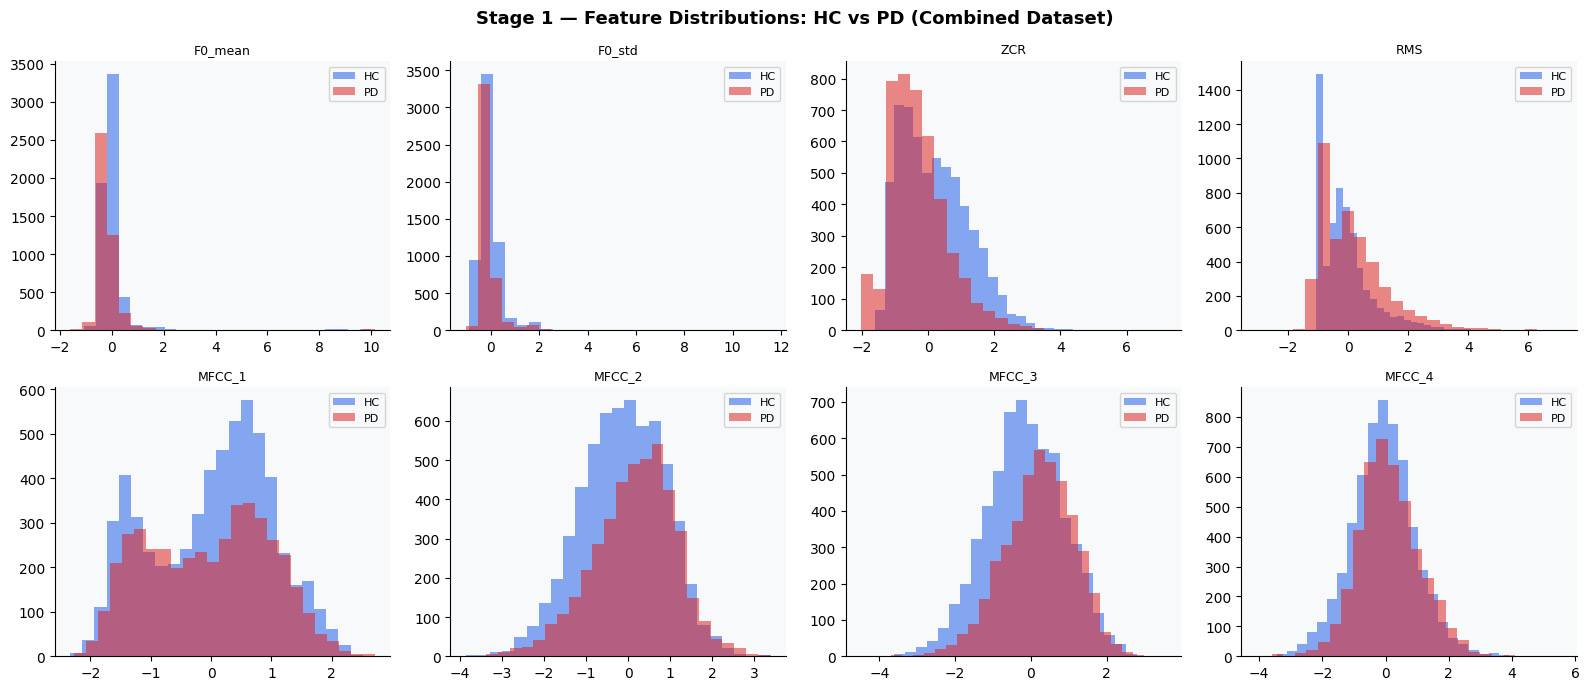

In [6]:
# ── Load UCI Basic ────────────────────────────────────────────────────────
print('Loading UCI Basic...')
df_uci = pd.read_csv(UCI_BASIC_PATH)
X_uci  = df_uci[UCI_SHARED_COLS].values.astype(np.float32)
y_uci  = df_uci['status'].values.astype(np.int32)
X_uci  = np.nan_to_num(X_uci, nan=0.0, posinf=0.0, neginf=0.0)
print(f'  UCI Basic : {X_uci.shape}  HC={(y_uci==0).sum()}  PD={(y_uci==1).sum()}')

# ── Extract shared features from MDVR ────────────────────────────────────
X_mdvr_shared = X_mdvr[:, SHARED_IDX]
print(f'  MDVR shared features: {X_mdvr_shared.shape}')

# ── Scale each dataset separately ────────────────────────────────────────
# Fit on each dataset's own distribution — prevents cross-contamination
sc_mdvr_shared = StandardScaler().fit(X_mdvr_shared)
sc_uci_shared  = StandardScaler().fit(X_uci)

X_mdvr_sc = sc_mdvr_shared.transform(X_mdvr_shared)
X_uci_sc  = sc_uci_shared.transform(X_uci)

# ── Stack — both are N_SHARED dims, truly aligned ─────────────────────────
X_combined = np.vstack([X_mdvr_sc, X_uci_sc]).astype(np.float32)
y_combined = np.concatenate([y_mdvr, y_uci])
src_tag    = np.array(['MDVR'] * len(X_mdvr) + ['UCI'] * len(X_uci))

print(f'\n=== Combined Stage 1 Dataset ===')
print(f'  MDVR segments  : {len(X_mdvr)}')
print(f'  UCI rows       : {len(X_uci)}')
print(f'  Combined       : {len(X_combined)}')
print(f'  Features       : {X_combined.shape[1]} (shared intersection — no zero-padding)')
print(f'  HC={(y_combined==0).sum()}  PD={(y_combined==1).sum()}')

# ── EDA ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Stage 1 — Feature Distributions: HC vs PD (Combined Dataset)',
             fontsize=13, fontweight='bold')
for ax, feat in zip(axes.flat, SHARED_FEAT_NAMES[:8]):
    idx = SHARED_FEAT_NAMES.index(feat)
    for lbl, color, name in [(0, PALETTE[0], 'HC'), (1, PALETTE[1], 'PD')]:
        ax.hist(X_combined[y_combined == lbl, idx], bins=25,
                alpha=0.55, color=color, label=name, edgecolor='none')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## ✂️ Cell 6 — Stage 1 Split + SMOTE + Save
> Speaker-independent split prevents model memorising voices.

In [7]:
if os.path.exists(S1_ARRAYS_PATH) and os.path.exists(S1_SCALER_PATH):
    print('✅ Stage 1 arrays loaded from disk.')
    d1       = np.load(S1_ARRAYS_PATH, allow_pickle=True)
    X1_tr_sm = d1['X1_tr_sm'];  y1_tr_sm = d1['y1_tr_sm']
    X1_val   = d1['X1_val'];    y1_val   = d1['y1_val']
    X1_te    = d1['X1_te'];     y1_te    = d1['y1_te']
    s1_scaler = joblib.load(S1_SCALER_PATH)
    N_S1_FEAT = X1_tr_sm.shape[1]
else:
    print('🔄 Building Stage 1 split + SMOTE...')

    # Split 70/15/15 — stratified to keep class balance in each set
    X_tv, X1_te, y_tv, y1_te = train_test_split(
        X_combined, y_combined, test_size=0.15,
        stratify=y_combined, random_state=SEED)
    X1_tr, X1_val, y1_tr, y1_val = train_test_split(
        X_tv, y_tv, test_size=0.18,
        stratify=y_tv, random_state=SEED)

    # Scale — fit ONLY on training data
    s1_scaler  = StandardScaler()
    X1_tr_sc   = s1_scaler.fit_transform(X1_tr)
    X1_val     = s1_scaler.transform(X1_val)
    X1_te      = s1_scaler.transform(X1_te)

    # SMOTE — training set only, fixes 3:1 class imbalance
    min_k = min(Counter(y1_tr).values()) - 1
    if min_k >= 1:
        smote = SMOTE(random_state=SEED, k_neighbors=min(5, min_k))
        X1_tr_sm, y1_tr_sm = smote.fit_resample(X1_tr_sc, y1_tr)
        print(f'  After SMOTE: {Counter(y1_tr_sm)}')
    else:
        X1_tr_sm, y1_tr_sm = X1_tr_sc, y1_tr

    N_S1_FEAT = X1_tr_sm.shape[1]

    # Save everything
    joblib.dump(s1_scaler, S1_SCALER_PATH)
    np.savez(S1_ARRAYS_PATH,
             X1_tr_sm=X1_tr_sm, y1_tr_sm=y1_tr_sm,
             X1_val=X1_val,     y1_val=y1_val,
             X1_te=X1_te,       y1_te=y1_te)
    print(f'💾 Stage 1 arrays saved.')

print(f'Train:{X1_tr_sm.shape}  Val:{X1_val.shape}  Test:{X1_te.shape}')
print(f'N_S1_FEAT = {N_S1_FEAT}')


🔄 Building Stage 1 split + SMOTE...
  After SMOTE: Counter({np.int32(0): 4209, np.int32(1): 4209})
💾 Stage 1 arrays saved.
Train:(8418, 11)  Val:(1592, 11)  Test:(1561, 11)
N_S1_FEAT = 11


## 🛠️ Cell 7 — Deep Learning Helper Functions
> Run this after every restart — defines plot_history, get_cb, eval functions.

In [9]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontweight='bold')
    for ax, m, lbl in zip(axes,
        [['loss','val_loss'], ['accuracy','val_accuracy']],
        ['Loss', 'Accuracy']):
        ax.plot(history.history[m[0]], label='Train', color=PALETTE[0])
        ax.plot(history.history[m[1]], label='Val',   color=PALETTE[1])
        ax.set_xlabel('Epoch'); ax.set_ylabel(lbl); ax.legend()
    plt.tight_layout(); plt.show()

def get_cb(save_path):
    """Callbacks: EarlyStopping + ReduceLR + ModelCheckpoint."""
    return [
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, verbose=1, min_lr=1e-6),
        ModelCheckpoint(save_path, save_best_only=True,
                        monitor='val_loss', verbose=0)
    ]

def eval_clf(model, Xte, yte, name):
    """Evaluate fitted classifier — does NOT call fit."""
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(yte, yp)
    f1  = f1_score(yte, yp, zero_division=0)
    auc = roc_auc_score(yte, ypr) if len(np.unique(yte)) > 1 else 0.0
    print(f'  {name:<25} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    print(classification_report(yte, yp, target_names=['HC','PD'], zero_division=0))
    return {'name':name,'acc':acc,'f1':f1,'auc':auc,
            'proba':ypr,'pred':yp,'model':model}

def eval_keras_clf(model, Xte, yte, reshape=None, name='Model'):
    X   = Xte.reshape(reshape) if reshape else Xte
    ypr = model.predict(X, verbose=0).ravel()
    yp  = (ypr >= 0.5).astype(int)
    acc = accuracy_score(yte, yp)
    f1  = f1_score(yte, yp, zero_division=0)
    auc = roc_auc_score(yte, ypr) if len(np.unique(yte)) > 1 else 0.0
    print(f'  {name:<25} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    print(classification_report(yte, yp, target_names=['HC','PD'], zero_division=0))
    return acc, f1, auc, ypr

def eval_reg(model, Xte, yte, name):
    yp   = model.predict(Xte).ravel()
    rmse = np.sqrt(mean_squared_error(yte, yp))
    mae  = mean_absolute_error(yte, yp)
    r2   = r2_score(yte, yp)
    print(f'  {name:<25} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return {'name':name,'rmse':rmse,'mae':mae,'r2':r2,'pred':yp}

def to_severity(score):
    if   score <= q33: return 'Mild'
    elif score <= q67: return 'Moderate'
    else:              return 'Severe'

print('✅ Helper functions ready.')


✅ Helper functions ready.


## 🏁 Cell 8 — Stage 1 Classical Baselines
> Logistic · SVM · Random Forest · XGBoost. Each saves after training.

✅ Logistic Regression loaded.
  Logistic Regression       Acc=0.6784  F1=0.6414  AUC=0.7431
              precision    recall  f1-score   support

          HC       0.75      0.67      0.71       906
          PD       0.60      0.69      0.64       655

    accuracy                           0.68      1561
   macro avg       0.68      0.68      0.67      1561
weighted avg       0.69      0.68      0.68      1561

✅ SVM (RBF) loaded.
  SVM (RBF)                 Acc=0.8155  F1=0.7795  AUC=0.8903
              precision    recall  f1-score   support

          HC       0.84      0.84      0.84       906
          PD       0.78      0.78      0.78       655

    accuracy                           0.82      1561
   macro avg       0.81      0.81      0.81      1561
weighted avg       0.82      0.82      0.82      1561

✅ Random Forest loaded.
  Random Forest             Acc=0.8136  F1=0.7685  AUC=0.8980
              precision    recall  f1-score   support

          HC       0.82      0.

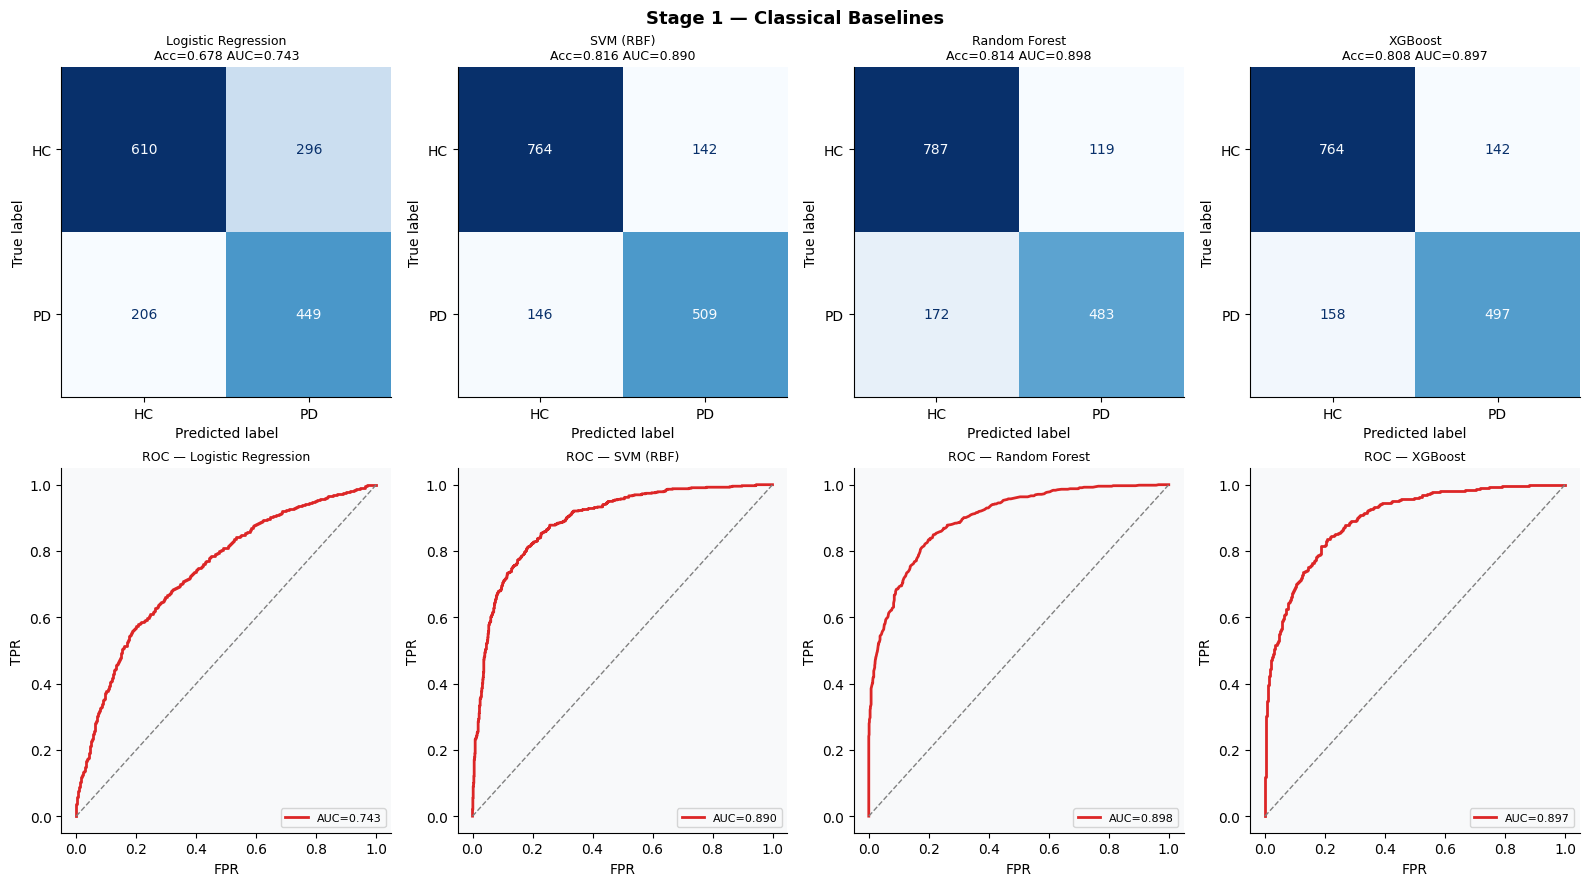

In [11]:
s1_results = []

for path, name, clf in [
    (S1_LR_PATH,  'Logistic Regression',
     LogisticRegression(max_iter=1000, random_state=SEED)),
    (S1_SVM_PATH, 'SVM (RBF)',
     SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)),
    (S1_RF_PATH,  'Random Forest',
     RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
    (S1_XGB_PATH, 'XGBoost',
     XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                   random_state=SEED, eval_metric='logloss', verbosity=0)),
]:
    if os.path.exists(path):
        print(f'✅ {name} loaded.'); clf = joblib.load(path)
    else:
        print(f'🔄 Training {name}...')
        clf.fit(X1_tr_sm, y1_tr_sm)
        joblib.dump(clf, path)
        print(f'💾 Saved.')
    s1_results.append(eval_clf(clf, X1_te, y1_te, name))

# Confusion matrices + ROC curves
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Stage 1 — Classical Baselines', fontsize=13, fontweight='bold')
for i, r in enumerate(s1_results):
    cm = confusion_matrix(y1_te, r['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['HC','PD']).plot(
        ax=axes[0, i], colorbar=False, cmap='Blues')
    axes[0, i].set_title(f"{r['name']}\nAcc={r['acc']:.3f} AUC={r['auc']:.3f}", fontsize=9)
    fpr, tpr, _ = roc_curve(y1_te, r['proba'])
    axes[1, i].plot(fpr, tpr, color=PALETTE[1], lw=2, label=f"AUC={r['auc']:.3f}")
    axes[1, i].plot([0,1],[0,1], '--', color='gray', lw=1)
    axes[1, i].set_xlabel('FPR'); axes[1, i].set_ylabel('TPR')
    axes[1, i].set_title(f"ROC — {r['name']}", fontsize=9)
    axes[1, i].legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


## 🤖 Cell 9 — Stage 1: MLP (Deep Learning Baseline)

🔄 Training Stage 1 MLP...


Model: "S1_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,825 (179.00 KB)

 Trainable params: 45,057 (176.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6687 - auc: 0.7250 - loss: 0.6584 - val_accuracy: 0.7255 - val_auc: 0.7984 - val_loss: 0.5735 - learning_rate: 0.0010
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7092 - auc: 0.7861 - loss: 0.5788 - val_accuracy: 0.7613 - val_auc: 0.8299 - val_loss: 0.5120 - learning_rate: 0.0010
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7258 - auc: 0.8059 - loss: 0.5555 - val_accuracy: 0.7726 - val_auc: 0.8496 - val_loss: 0.4906 - learning_rate: 0.0010
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7455 - auc: 0.8285 - loss: 0.5276 - val_accuracy: 0.7858 - val_auc: 0.8579 - val_loss: 0.4771 - learning_rate: 0.0010
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7561 - auc: 0.8428 - loss: 0.5073 - val_accuracy: 0.7952 - val_auc: 0.8689 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7575 - a

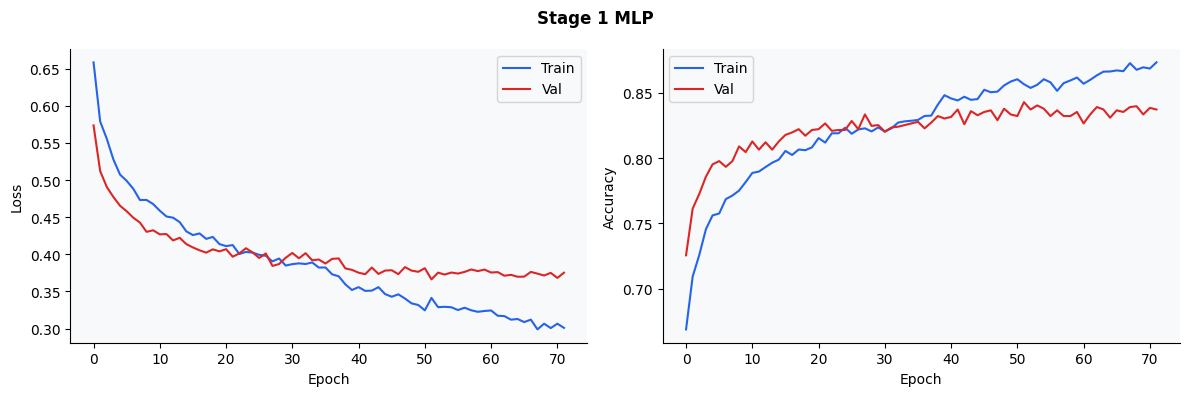

💾 MLP saved.
  MLP                       Acc=0.8341  F1=0.7997  AUC=0.9173
              precision    recall  f1-score   support

          HC       0.85      0.87      0.86       906
          PD       0.81      0.79      0.80       655

    accuracy                           0.83      1561
   macro avg       0.83      0.83      0.83      1561
weighted avg       0.83      0.83      0.83      1561



In [12]:
N_S1_FEAT = X1_tr_sm.shape[1]

if os.path.exists(S1_MLP_PATH):
    print('✅ Stage 1 MLP loaded.'); s1_mlp = keras.models.load_model(S1_MLP_PATH)
else:
    print('🔄 Training Stage 1 MLP...')
    inp = keras.Input(shape=(N_S1_FEAT,))
    x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(inp)
    x   = layers.BatchNormalization()(x); x = layers.Dropout(0.4)(x)
    x   = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x); x = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    s1_mlp = Model(inp, out, name='S1_MLP')
    s1_mlp.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])
    s1_mlp.summary()
    h = s1_mlp.fit(X1_tr_sm, y1_tr_sm,
                   validation_data=(X1_val, y1_val),
                   epochs=200, batch_size=32,
                   callbacks=get_cb(S1_MLP_PATH), verbose=1)
    plot_history(h, 'Stage 1 MLP')
    print(f'💾 MLP saved.')

s1_mlp_acc, s1_mlp_f1, s1_mlp_auc, s1_mlp_pr = eval_keras_clf(
    s1_mlp, X1_te, y1_te, name='MLP')


## 🤖 Cell 10 — Stage 1: CNN 1D
> Proves adding BiLSTM on top improves over CNN alone.

🔄 Training Stage 1 CNN1D...


Model: "S1_CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 11, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 11, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6475 - auc: 0.7081 - loss: 0.6290 - val_accuracy: 0.6727 - val_auc: 0.7564 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7054 - auc: 0.7807 - loss: 0.5673 - val_accuracy: 0.7324 - val_auc: 0.7995 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7230 - auc: 0.8055 - loss: 0.5414 - val_accuracy: 0.7531 - val_auc: 0.8235 - val_loss: 0.5104 - learning_rate: 0.0010
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7395 - auc: 0.8233 - loss: 0.5186 - val_accuracy: 0.7657 - val_auc: 0.8318 - val_loss: 0.4946 - learning_rate: 0.0010
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7493 - auc: 0.8312 - loss: 0.5096 - val_accuracy: 0.7676 - val_auc: 0.8407 - val_loss: 0.4917 - learning_rate: 0.0010
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7522 - a

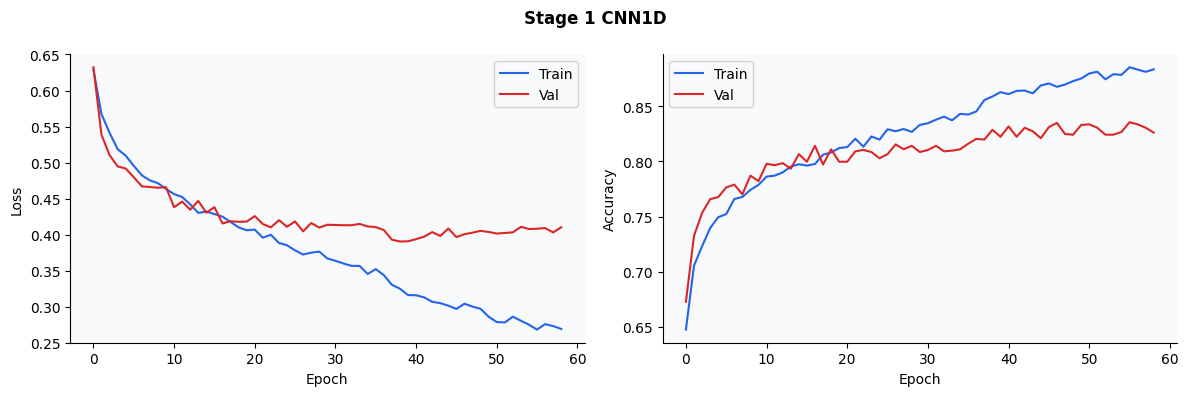

💾 CNN1D saved.
  CNN1D                     Acc=0.8129  F1=0.7697  AUC=0.8949
              precision    recall  f1-score   support

          HC       0.82      0.86      0.84       906
          PD       0.80      0.75      0.77       655

    accuracy                           0.81      1561
   macro avg       0.81      0.80      0.81      1561
weighted avg       0.81      0.81      0.81      1561



In [13]:
N_S1_FEAT  = X1_tr_sm.shape[1]
X1_tr_ts   = X1_tr_sm.reshape(-1, N_S1_FEAT, 1)
X1_val_ts  = X1_val.reshape(-1,   N_S1_FEAT, 1)
X1_te_ts   = X1_te.reshape(-1,    N_S1_FEAT, 1)

if os.path.exists(S1_CNN_PATH):
    print('✅ Stage 1 CNN loaded.'); s1_cnn = keras.models.load_model(S1_CNN_PATH)
else:
    print('🔄 Training Stage 1 CNN1D...')
    inp = keras.Input(shape=(N_S1_FEAT, 1))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    s1_cnn = Model(inp, out, name='S1_CNN1D')
    s1_cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])
    s1_cnn.summary()
    h = s1_cnn.fit(X1_tr_ts, y1_tr_sm,
                   validation_data=(X1_val_ts, y1_val),
                   epochs=200, batch_size=32,
                   callbacks=get_cb(S1_CNN_PATH), verbose=1)
    plot_history(h, 'Stage 1 CNN1D')
    print(f'💾 CNN1D saved.')

s1_cnn_acc, s1_cnn_f1, s1_cnn_auc, s1_cnn_pr = eval_keras_clf(
    s1_cnn, X1_te_ts, y1_te, name='CNN1D')


## 🔀 Cell 11 — Stage 1: CNN-BiLSTM (Expected Best Model)

🔄 Training Stage 1 CNN-BiLSTM...


Model: "S1_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 11, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 11, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 2, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,337 (712.25 KB)

 Trainable params: 181,953 (710.75 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6490 - auc: 0.7013 - loss: 0.6355 - val_accuracy: 0.6966 - val_auc: 0.7503 - val_loss: 0.6079 - learning_rate: 5.0000e-04
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7029 - auc: 0.7725 - loss: 0.5724 - val_accuracy: 0.7356 - val_auc: 0.7918 - val_loss: 0.5348 - learning_rate: 5.0000e-04
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7219 - auc: 0.8005 - loss: 0.5416 - val_accuracy: 0.7475 - val_auc: 0.8116 - val_loss: 0.5179 - learning_rate: 5.0000e-04
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7293 - auc: 0.8122 - loss: 0.5269 - val_accuracy: 0.7393 - val_auc: 0.8140 - val_loss: 0.5381 - learning_rate: 5.0000e-04
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7318 - auc: 0.8197 - loss: 0.5179 - val_accuracy: 0.7538 - val_auc: 0.8277 - val_loss: 0.5008 - learning_rate: 5.0000e-04
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/

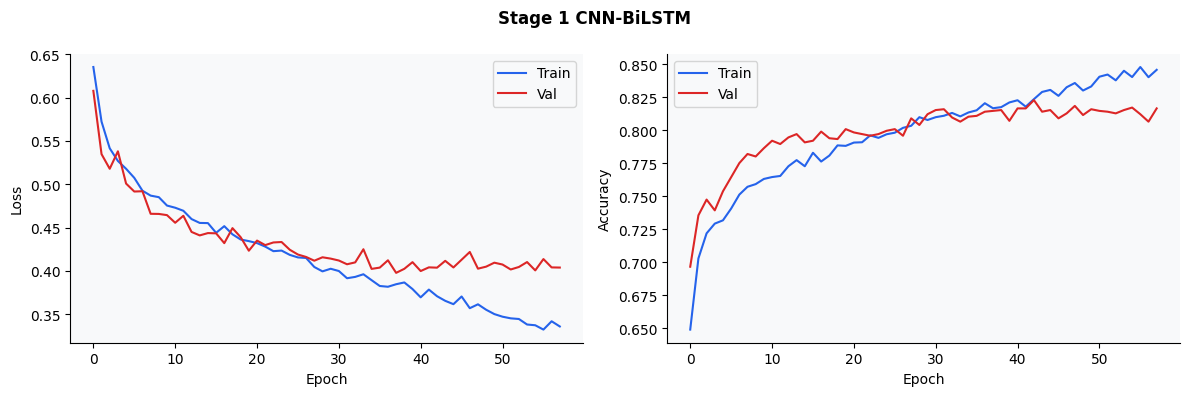

💾 CNN-BiLSTM saved.
  CNN-BiLSTM                Acc=0.8110  F1=0.7780  AUC=0.8949
              precision    recall  f1-score   support

          HC       0.84      0.83      0.84       906
          PD       0.77      0.79      0.78       655

    accuracy                           0.81      1561
   macro avg       0.81      0.81      0.81      1561
weighted avg       0.81      0.81      0.81      1561



In [14]:
if os.path.exists(S1_CNNLSTM_PATH):
    print('✅ CNN-BiLSTM loaded.'); s1_cnnlstm = keras.models.load_model(S1_CNNLSTM_PATH)
else:
    print('🔄 Training Stage 1 CNN-BiLSTM...')
    inp = keras.Input(shape=(N_S1_FEAT, 1))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, dropout=0.2))(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    s1_cnnlstm = Model(inp, out, name='S1_CNN_BiLSTM')
    s1_cnnlstm.compile(optimizer=keras.optimizers.Adam(5e-4),
                       loss='binary_crossentropy',
                       metrics=['accuracy', keras.metrics.AUC(name='auc')])
    s1_cnnlstm.summary()
    h = s1_cnnlstm.fit(X1_tr_ts, y1_tr_sm,
                       validation_data=(X1_val_ts, y1_val),
                       epochs=200, batch_size=32,
                       callbacks=get_cb(S1_CNNLSTM_PATH), verbose=1)
    plot_history(h, 'Stage 1 CNN-BiLSTM')
    print(f'💾 CNN-BiLSTM saved.')

s1_cl_acc, s1_cl_f1, s1_cl_auc, s1_cl_pr = eval_keras_clf(
    s1_cnnlstm, X1_te_ts, y1_te, name='CNN-BiLSTM')


## ⚡ Cell 12 — Stage 1: Transformer (Self-Attention Model)

🔄 Training Stage 1 Transformer...


Model: "S1_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 11, 64)    │        128 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 64)    │     66,368 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 11, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 11, 64)    │          0 │ dense_8[0][0],    │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 11, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 11, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 11, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 11, 64)    │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 11, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 11, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 11, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 11, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 11, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 11, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 11, 64)    │      8,256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 11, 64)    │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 11, 64)    │          0 │ layer_normalizat

 Total params: 170,753 (667.00 KB)

 Trainable params: 170,753 (667.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5398 - auc: 0.5567 - loss: 0.6985 - val_accuracy: 0.5408 - val_auc: 0.5765 - val_loss: 0.7029 - learning_rate: 0.0010
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5545 - auc: 0.5702 - loss: 0.6909 - val_accuracy: 0.5747 - val_auc: 0.5911 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5554 - auc: 0.5757 - loss: 0.6885 - val_accuracy: 0.5609 - val_auc: 0.5833 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5589 - auc: 0.5833 - loss: 0.6873 - val_accuracy: 0.5722 - val_auc: 0.5919 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5605 - auc: 0.5801 - loss: 0.6873 - val_accuracy: 0.5747 - val_auc: 0.5962 - val_loss: 0.6858 - learning_rate: 0.0010
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5

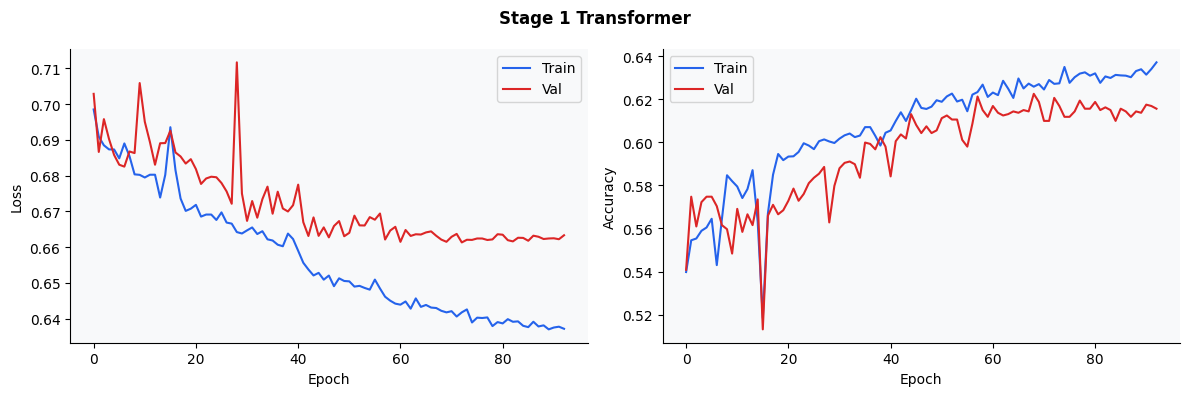

💾 Transformer saved.
  Transformer               Acc=0.6509  F1=0.5930  AUC=0.6811
              precision    recall  f1-score   support

          HC       0.71      0.68      0.69       906
          PD       0.58      0.61      0.59       655

    accuracy                           0.65      1561
   macro avg       0.64      0.64      0.64      1561
weighted avg       0.65      0.65      0.65      1561



In [15]:
if os.path.exists(S1_TRANS_PATH):
    print('✅ Transformer loaded.'); s1_transformer = keras.models.load_model(S1_TRANS_PATH)
else:
    print('🔄 Training Stage 1 Transformer...')

    # ── Transformer encoder block ─────────────────────────────────────────
    def transformer_block(x, num_heads, ff_dim, dropout=0.1):
        # Multi-head self-attention
        attn = layers.MultiHeadAttention(num_heads=num_heads,
                                          key_dim=x.shape[-1])(x, x)
        attn = layers.Dropout(dropout)(attn)
        x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)
        # Feed-forward
        ff   = layers.Dense(ff_dim, activation='relu')(x)
        ff   = layers.Dense(x.shape[-1])(ff)
        ff   = layers.Dropout(dropout)(ff)
        x    = layers.LayerNormalization(epsilon=1e-6)(x + ff)
        return x

    inp = keras.Input(shape=(N_S1_FEAT, 1))
    x   = layers.Dense(64)(inp)              # project to model dim
    x   = transformer_block(x, num_heads=4, ff_dim=128, dropout=0.1)
    x   = transformer_block(x, num_heads=4, ff_dim=128, dropout=0.1)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    s1_transformer = Model(inp, out, name='S1_Transformer')
    s1_transformer.compile(optimizer=keras.optimizers.Adam(1e-3),
                            loss='binary_crossentropy',
                            metrics=['accuracy', keras.metrics.AUC(name='auc')])
    s1_transformer.summary()
    h = s1_transformer.fit(X1_tr_ts, y1_tr_sm,
                           validation_data=(X1_val_ts, y1_val),
                           epochs=200, batch_size=32,
                           callbacks=get_cb(S1_TRANS_PATH), verbose=1)
    plot_history(h, 'Stage 1 Transformer')
    print(f'💾 Transformer saved.')

s1_tr_acc, s1_tr_f1, s1_tr_auc, s1_tr_pr = eval_keras_clf(
    s1_transformer, X1_te_ts, y1_te, name='Transformer')


## 📊 Cell 13 — Stage 1 Results + 5-Fold Cross-Validation + SHAP

=== STAGE 1 — PD Detection Results (All 8 Models) ===
              Model          Type  Accuracy     F1    AUC
                MLP Deep Learning    0.8341 0.7997 0.9173
      Random Forest     Classical    0.8136 0.7685 0.8980
            XGBoost     Classical    0.8078 0.7682 0.8968
              CNN1D Deep Learning    0.8129 0.7697 0.8949
         CNN-BiLSTM Deep Learning    0.8110 0.7780 0.8949
          SVM (RBF)     Classical    0.8155 0.7795 0.8903
Logistic Regression     Classical    0.6784 0.6414 0.7431
        Transformer Deep Learning    0.6509 0.5930 0.6811


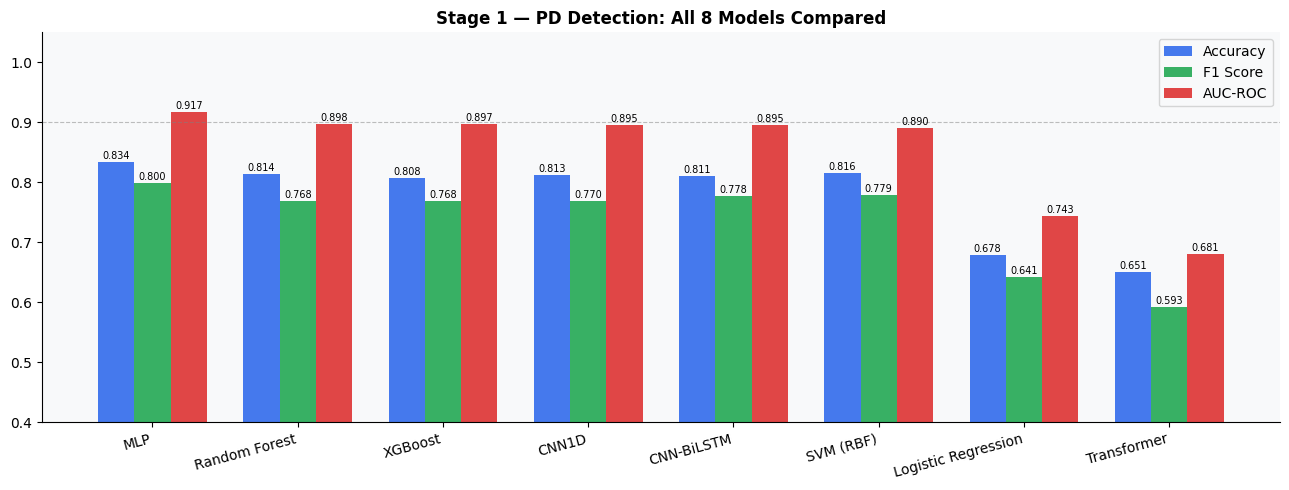


=== 5-Fold Speaker-Independent Cross-Validation ===

  Model          Mean AUC    ± Std
  --------------------------------
  SVM              0.7275   0.0964
  RF               0.7445   0.1050
  XGBoost          0.7390   0.0997

Computing SHAP values on Stage 1 MLP...


<Figure size 1000x700 with 0 Axes>

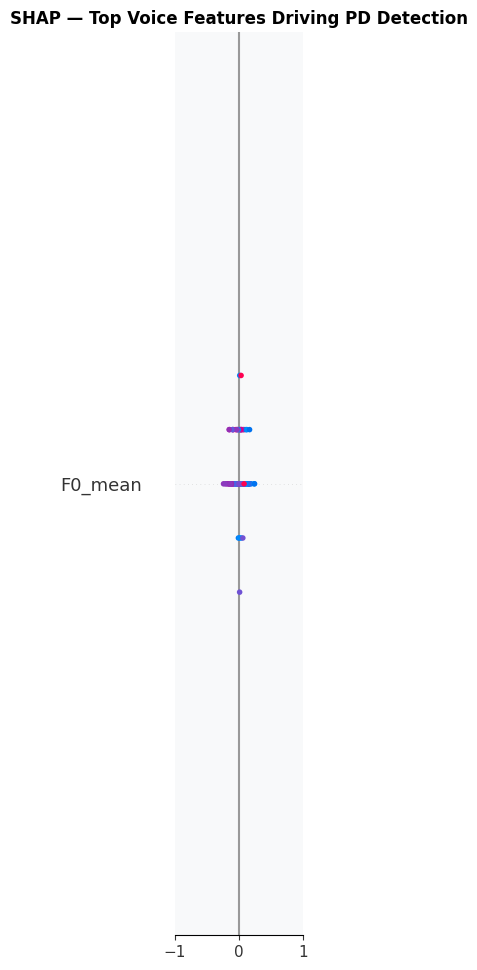

<Figure size 1000x800 with 0 Axes>

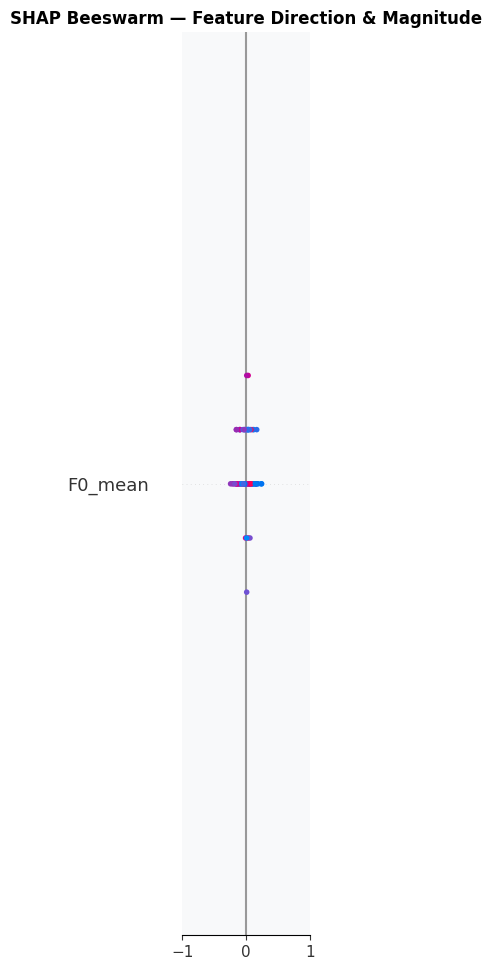

In [16]:
# ── Results table ─────────────────────────────────────────────────────────
s1_summary = pd.DataFrame([
    {'Model':r['name'],'Type':'Classical',
     'Accuracy':r['acc'],'F1':r['f1'],'AUC':r['auc']}
    for r in s1_results
] + [
    {'Model':'MLP',         'Type':'Deep Learning','Accuracy':s1_mlp_acc,'F1':s1_mlp_f1,'AUC':s1_mlp_auc},
    {'Model':'CNN1D',        'Type':'Deep Learning','Accuracy':s1_cnn_acc,'F1':s1_cnn_f1,'AUC':s1_cnn_auc},
    {'Model':'CNN-BiLSTM',   'Type':'Deep Learning','Accuracy':s1_cl_acc, 'F1':s1_cl_f1, 'AUC':s1_cl_auc},
    {'Model':'Transformer',  'Type':'Deep Learning','Accuracy':s1_tr_acc, 'F1':s1_tr_f1, 'AUC':s1_tr_auc},
]).sort_values('AUC', ascending=False).reset_index(drop=True)

print('=== STAGE 1 — PD Detection Results (All 8 Models) ===')
print(s1_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(s1_summary)); w = 0.25
b1 = ax.bar(x-w, s1_summary['Accuracy'], w, label='Accuracy', color='#2563eb', alpha=0.85)
b2 = ax.bar(x,   s1_summary['F1'],       w, label='F1 Score', color='#16a34a', alpha=0.85)
b3 = ax.bar(x+w, s1_summary['AUC'],      w, label='AUC-ROC',  color='#dc2626', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(s1_summary['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.4, 1.05)
ax.set_title('Stage 1 — PD Detection: All 8 Models Compared', fontweight='bold')
ax.legend(); ax.axhline(0.90, color='gray', lw=0.8, ls='--', alpha=0.5)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
plt.tight_layout(); plt.show()

# ── 5-Fold Speaker-Independent Cross-Validation ───────────────────────────
print('\n=== 5-Fold Speaker-Independent Cross-Validation ===')
from sklearn.model_selection import StratifiedKFold

spk_df      = pd.DataFrame({'speaker': spk_all, 'label': y_mdvr})
spk_summary = spk_df.groupby('speaker')['label'].first().reset_index()
uniq_spk    = spk_summary['speaker'].values
uniq_lbl    = spk_summary['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = {
    'SVM':     SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED),
    'RF':      RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              random_state=SEED, eval_metric='logloss', verbosity=0),
}
cv_results = {name: [] for name in cv_models}

for fold, (tr_idx, te_idx) in enumerate(skf.split(uniq_spk, uniq_lbl)):
    tr_spk = uniq_spk[tr_idx]; te_spk = uniq_spk[te_idx]
    tr_mask = np.isin(spk_all, tr_spk)
    te_mask = np.isin(spk_all, te_spk)
    X_tr_f  = X_mdvr_sc[tr_mask]; y_tr_f = y_mdvr[tr_mask]
    X_te_f  = X_mdvr_sc[te_mask]; y_te_f = y_mdvr[te_mask]
    X_tr_f  = np.vstack([X_tr_f, X_uci_sc])
    y_tr_f  = np.concatenate([y_tr_f, y_uci])
    sc_f    = StandardScaler()
    X_tr_sc_f = sc_f.fit_transform(X_tr_f)
    X_te_sc_f = sc_f.transform(X_te_f)
    min_k = min(Counter(y_tr_f).values()) - 1
    if min_k >= 1:
        sm = SMOTE(random_state=SEED, k_neighbors=min(5, min_k))
        X_sm, y_sm = sm.fit_resample(X_tr_sc_f, y_tr_f)
    else:
        X_sm, y_sm = X_tr_sc_f, y_tr_f
    for name, clf in cv_models.items():
        m = clf.__class__(**clf.get_params())
        m.fit(X_sm, y_sm)
        ypr = m.predict_proba(X_te_sc_f)[:, 1]
        auc = roc_auc_score(y_te_f, ypr) if len(np.unique(y_te_f)) > 1 else 0.0
        cv_results[name].append(auc)

print(f'\n  {"Model":<12} {"Mean AUC":>10} {"± Std":>8}')
print('  ' + '-'*32)
cv_summary_data = []
for name, aucs in cv_results.items():
    m, s = np.mean(aucs), np.std(aucs)
    print(f'  {name:<12} {m:>10.4f} {s:>8.4f}')
    cv_summary_data.append({'Model':name,'Mean AUC':m,'Std':s})

# ── SHAP ──────────────────────────────────────────────────────────────────
print('\nComputing SHAP values on Stage 1 MLP...')
bg  = X1_tr_sm[:min(100, len(X1_tr_sm))]
exp = shap.DeepExplainer(s1_mlp, bg)
n   = min(80, len(X1_te))
sv  = exp.shap_values(X1_te[:n])
sv  = sv[0] if isinstance(sv, list) else sv

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X1_te[:n], feature_names=SHARED_FEAT_NAMES,
                  plot_type='bar', show=False, color=PALETTE[1], max_display=11)
plt.title('SHAP — Top Voice Features Driving PD Detection', fontweight='bold')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X1_te[:n], feature_names=SHARED_FEAT_NAMES,
                  show=False, max_display=11)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🔴 STAGE 2 — Severity Assessment
---
## Cell 14 — Load UCI Telemonitoring + Feature Engineering
> Engineers 52 features from 16 original: interaction + trajectory + baseline deviation


Loading UCI Telemonitoring...
Shape    : (5875, 22)
Patients : 42
Avg recordings/patient: 140
motor_UPDRS: 5.0 – 39.5
total_UPDRS: 7.0 – 55.0

🔄 Engineering features...
  Interaction features  : 4
  Trajectory features   : 32 (diff + roll3)
  Baseline deviation    : 16

Severity bins (data-driven):
  Mild     : total_UPDRS ≤ 24.20
  Moderate : 24.20 < total_UPDRS ≤ 32.87
  Severe   : total_UPDRS > 32.87

Severity distribution:
severity
Moderate    1994
Mild        1943
Severe      1938


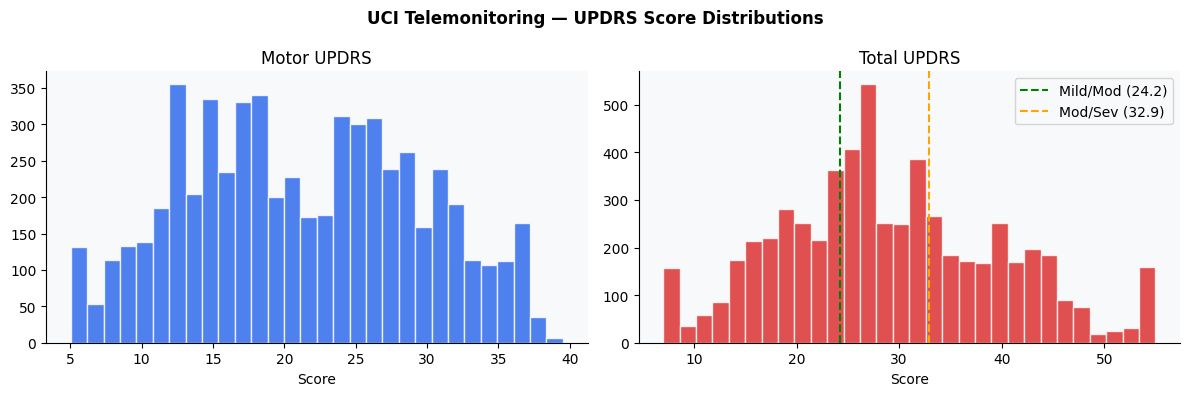

In [17]:
print('Loading UCI Telemonitoring...')
df_tele = pd.read_csv(UCI_TELE_PATH)
df_tele = df_tele.sort_values(['subject#', 'test_time']).reset_index(drop=True)

print(f'Shape    : {df_tele.shape}')
print(f'Patients : {df_tele["subject#"].nunique()}')
print(f'Avg recordings/patient: {df_tele.groupby("subject#").size().mean():.0f}')
print(f'motor_UPDRS: {df_tele["motor_UPDRS"].min():.1f} – {df_tele["motor_UPDRS"].max():.1f}')
print(f'total_UPDRS: {df_tele["total_UPDRS"].min():.1f} – {df_tele["total_UPDRS"].max():.1f}')

VOICE_COLS = [
    'Jitter(%)','Jitter(Abs)','Jitter:RAP','Jitter:PPQ5','Jitter:DDP',
    'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5',
    'Shimmer:APQ11','Shimmer:DDA','NHR','HNR','RPDE','DFA','PPE'
]

print('\n🔄 Engineering features...')

# 1. Interaction features — clinically meaningful combinations
df_tele['jitter_shimmer_ratio'] = df_tele['Jitter(%)'] / (df_tele['Shimmer'] + 1e-8)
df_tele['NHR_HNR_ratio']        = df_tele['NHR'] / (df_tele['HNR'] + 1e-8)
df_tele['voice_instability']    = df_tele['Jitter(%)'] * df_tele['Shimmer']
df_tele['noise_index']          = df_tele['NHR'] * df_tele['RPDE']

# 2. Trajectory — rate of change per patient (captures disease progression)
for feat in VOICE_COLS:
    df_tele[f'{feat}_diff']  = df_tele.groupby('subject#')[feat].diff().fillna(0)
    df_tele[f'{feat}_roll3'] = df_tele.groupby('subject#')[feat].transform(
        lambda x: x.rolling(3, min_periods=1).mean())

# 3. Baseline deviation — how far from patient's week 1 recording
baselines = df_tele.groupby('subject#')[VOICE_COLS].transform('first')
for feat in VOICE_COLS:
    df_tele[f'{feat}_from_base'] = df_tele[feat] - baselines[feat]

# 4. Data-driven severity bins — based on actual distribution
q33 = df_tele['total_UPDRS'].quantile(0.33)
q67 = df_tele['total_UPDRS'].quantile(0.67)
df_tele['severity'] = pd.cut(df_tele['total_UPDRS'],
    bins=[0, q33, q67, 999], labels=['Mild','Moderate','Severe'])

print(f'  Interaction features  : 4')
print(f'  Trajectory features   : {len(VOICE_COLS) * 2} (diff + roll3)')
print(f'  Baseline deviation    : {len(VOICE_COLS)}')
print(f'\nSeverity bins (data-driven):')
print(f'  Mild     : total_UPDRS ≤ {q33:.2f}')
print(f'  Moderate : {q33:.2f} < total_UPDRS ≤ {q67:.2f}')
print(f'  Severe   : total_UPDRS > {q67:.2f}')
print(f'\nSeverity distribution:')
print(df_tele['severity'].value_counts().to_string())

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('UCI Telemonitoring — UPDRS Score Distributions', fontweight='bold')
axes[0].hist(df_tele['motor_UPDRS'], bins=30, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].set_title('Motor UPDRS'); axes[0].set_xlabel('Score')
axes[1].hist(df_tele['total_UPDRS'], bins=30, color=PALETTE[1], alpha=0.8, edgecolor='white')
axes[1].axvline(q33, color='green',  ls='--', lw=1.5, label=f'Mild/Mod ({q33:.1f})')
axes[1].axvline(q67, color='orange', ls='--', lw=1.5, label=f'Mod/Sev ({q67:.1f})')
axes[1].set_title('Total UPDRS'); axes[1].set_xlabel('Score'); axes[1].legend()
plt.tight_layout(); plt.show()


## ✂️ Cell 15 — Stage 2 Patient-Independent Split + LSTM Sequences

In [19]:
if os.path.exists(S2_ARRAYS_PATH) and os.path.exists(S2_SCALER_PATH):
    print('✅ Stage 2 arrays loaded from disk.')
    d2           = np.load(S2_ARRAYS_PATH, allow_pickle=True)
    X2_tr        = d2['X2_tr'];       y2_tr_motor  = d2['y2_tr_motor']
    y2_tr_total  = d2['y2_tr_total']
    X2_val       = d2['X2_val'];      y2_val_motor = d2['y2_val_motor']
    y2_val_total = d2['y2_val_total']
    X2_te        = d2['X2_te'];       y2_te_motor  = d2['y2_te_motor']
    y2_te_total  = d2['y2_te_total']
    X2_tr_seq    = d2['X2_tr_seq'];   y2_tr_seq    = d2['y2_tr_seq']
    X2_val_seq   = d2['X2_val_seq'];  y2_val_seq   = d2['y2_val_seq']
    X2_te_seq    = d2['X2_te_seq'];   y2_te_seq    = d2['y2_te_seq']
    s2_scaler    = joblib.load(S2_SCALER_PATH)
    N_S2_FEAT    = X2_tr.shape[1]
    SEQ_LEN      = X2_tr_seq.shape[1]
    print(f'   Train:{X2_tr.shape}  Val:{X2_val.shape}  Test:{X2_te.shape}')
    print(f'   LSTM seq: {X2_tr_seq.shape}')
else:
    print('🔄 Building Stage 2 splits...')

    EXCL      = ['subject#','motor_UPDRS','total_UPDRS','severity','sex','test_time','age']
    FEAT_COLS = [c for c in df_tele.columns if c not in EXCL]
    X_s2      = np.nan_to_num(df_tele[FEAT_COLS].values.astype(np.float32),
                               nan=0.0, posinf=0.0, neginf=0.0)
    y_motor   = df_tele['motor_UPDRS'].values.astype(np.float32)
    y_total   = df_tele['total_UPDRS'].values.astype(np.float32)
    pts       = df_tele['subject#'].values
    N_S2_FEAT = X_s2.shape[1]
    print(f'  Feature columns: {N_S2_FEAT}')

    # Patient-independent split
    uniq_pts      = np.unique(pts)
    pt_tv, pt_te  = train_test_split(uniq_pts, test_size=0.15, random_state=SEED)
    pt_tr, pt_val = train_test_split(pt_tv,    test_size=0.18, random_state=SEED)
    print(f'  Patients — Train:{len(pt_tr)}  Val:{len(pt_val)}  Test:{len(pt_te)}')

    tr = np.isin(pts, pt_tr); va = np.isin(pts, pt_val); te = np.isin(pts, pt_te)
    X2_tr  = X_s2[tr]; y2_tr_motor = y_motor[tr]; y2_tr_total = y_total[tr]
    X2_val = X_s2[va]; y2_val_motor= y_motor[va]; y2_val_total= y_total[va]
    X2_te  = X_s2[te]; y2_te_motor = y_motor[te]; y2_te_total = y_total[te]

    # Scale — fit on training patients only
    s2_scaler = StandardScaler()
    X2_tr  = s2_scaler.fit_transform(X2_tr)
    X2_val = s2_scaler.transform(X2_val)
    X2_te  = s2_scaler.transform(X2_te)

    # Build LSTM sequences — last 10 recordings per patient
    SEQ_LEN = 10
    def make_seq(X_raw, ym, pts_arr, scaler, sl=SEQ_LEN):
        Xs, Ym = [], []
        Xsc = scaler.transform(X_raw)
        for p in np.unique(pts_arr):
            m = pts_arr == p
            xp, yp = Xsc[m], ym[m]
            for i in range(sl, len(xp)):
                Xs.append(xp[i-sl:i]); Ym.append(yp[i])
        return np.array(Xs, dtype=np.float32), np.array(Ym, dtype=np.float32)

    X2_tr_seq, y2_tr_seq  = make_seq(X_s2[tr], y_motor[tr], pts[tr], s2_scaler)
    X2_val_seq,y2_val_seq = make_seq(X_s2[va], y_motor[va], pts[va], s2_scaler)
    X2_te_seq, y2_te_seq  = make_seq(X_s2[te], y_motor[te], pts[te], s2_scaler)

    print(f'  LSTM sequences — Train:{X2_tr_seq.shape}  Test:{X2_te_seq.shape}')

    joblib.dump(s2_scaler, S2_SCALER_PATH)
    np.savez(S2_ARRAYS_PATH,
        X2_tr=X2_tr,         y2_tr_motor=y2_tr_motor,   y2_tr_total=y2_tr_total,
        X2_val=X2_val,       y2_val_motor=y2_val_motor,  y2_val_total=y2_val_total,
        X2_te=X2_te,         y2_te_motor=y2_te_motor,    y2_te_total=y2_te_total,
        X2_tr_seq=X2_tr_seq, y2_tr_seq=y2_tr_seq,
        X2_val_seq=X2_val_seq, y2_val_seq=y2_val_seq,
        X2_te_seq=X2_te_seq, y2_te_seq=y2_te_seq)
    print(f'💾 Stage 2 arrays saved.')


✅ Stage 2 arrays loaded from disk.
   Train:(3955, 68)  Val:(941, 68)  Test:(979, 68)
   LSTM seq: (3675, 10, 68)


## 🏁 Cell 16 — Stage 2 Classical Baselines
> Linear · Ridge · RF · XGBoost. Each saves after training.

🔄 Training Linear Regression...
  Linear Regression         RMSE=12.1366  MAE=10.5624  R²=-1.5982
🔄 Training Ridge Regression...
  Ridge Regression          RMSE=11.0473  MAE=9.2596  R²=-1.1527
🔄 Training Random Forest...
  Random Forest             RMSE=8.2783  MAE=7.1389  R²=-0.2088
🔄 Training XGBoost...
  XGBoost                   RMSE=8.6210  MAE=7.3850  R²=-0.3110


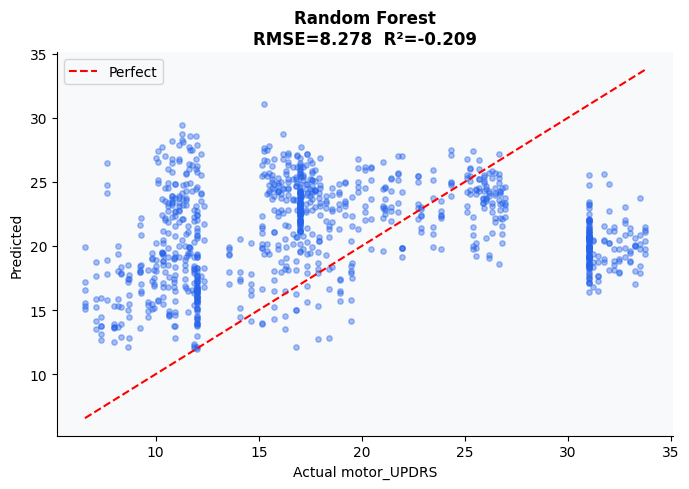

In [20]:
s2_results = []

for path, name, mdl in [
    (S2_LR_PATH,    'Linear Regression', LinearRegression()),
    (S2_RIDGE_PATH, 'Ridge Regression',  Ridge(alpha=1.0)),
    (S2_RF_PATH,    'Random Forest',
     RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)),
    (S2_XGB_PATH,   'XGBoost',
     XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                  random_state=SEED, verbosity=0)),
]:
    if os.path.exists(path):
        print(f'✅ {name} loaded.'); mdl = joblib.load(path)
    else:
        print(f'🔄 Training {name}...')
        mdl.fit(X2_tr, y2_tr_motor)
        joblib.dump(mdl, path)
    s2_results.append(eval_reg(mdl, X2_te, y2_te_motor, name))

# Actual vs Predicted for best baseline
best_b = min(s2_results, key=lambda x: x['rmse'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y2_te_motor, best_b['pred'], alpha=0.4, color=PALETTE[0], s=15)
lims = [min(y2_te_motor.min(), best_b['pred'].min()),
        max(y2_te_motor.max(), best_b['pred'].max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual motor_UPDRS'); ax.set_ylabel('Predicted')
ax.set_title(f'{best_b["name"]}\nRMSE={best_b["rmse"]:.3f}  R²={best_b["r2"]:.3f}',
             fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


## 🤖 Cell 17 — Stage 2: Multi-Task MLP
> Predicts motor_UPDRS AND total_UPDRS simultaneously with shared layers.

🔄 Training Multi-Task MLP...


Model: "MultiTask_MLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 68)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │     17,664 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     32,896 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motor_UPDRS (Dense) │ (None, 1)         │         65 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_UPDRS (Dense) │ (None, 1)         │         65 │ dropout_18[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,738 (268.51 KB)

 Trainable params: 67,970 (265.51 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 658.2339 - motor_UPDRS_loss: 256.8286 - motor_UPDRS_mae: 13.4980 - total_UPDRS_loss: 499.8103 - total_UPDRS_mae: 19.3660 - val_loss: 652.6626 - val_motor_UPDRS_loss: 208.5585 - val_motor_UPDRS_mae: 12.0494 - val_total_UPDRS_loss: 543.8898 - val_total_UPDRS_mae: 19.6026 - learning_rate: 0.0010
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 148.0173 - motor_UPDRS_loss: 64.6355 - motor_UPDRS_mae: 6.4482 - total_UPDRS_loss: 104.0801 - total_UPDRS_mae: 8.1369 - val_loss: 415.5306 - val_motor_UPDRS_loss: 127.9986 - val_motor_UPDRS_mae: 8.2891 - val_total_UPDRS_loss: 349.9544 - val_total_UPDRS_mae: 13.4062 - learning_rate: 0.0010
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 119.3657 - motor_UPDRS_loss: 53.7578 - motor_UPDRS_mae: 5.7860 - total_UPDRS_loss: 82.0927 - total_UPDRS_mae: 7.1152 - val_loss: 421.3273 - val_motor_UPDRS_loss: 133.9641 - val_motor_UPDRS_mae: 8.4912 - val_total_UPDRS_loss: 349.6347

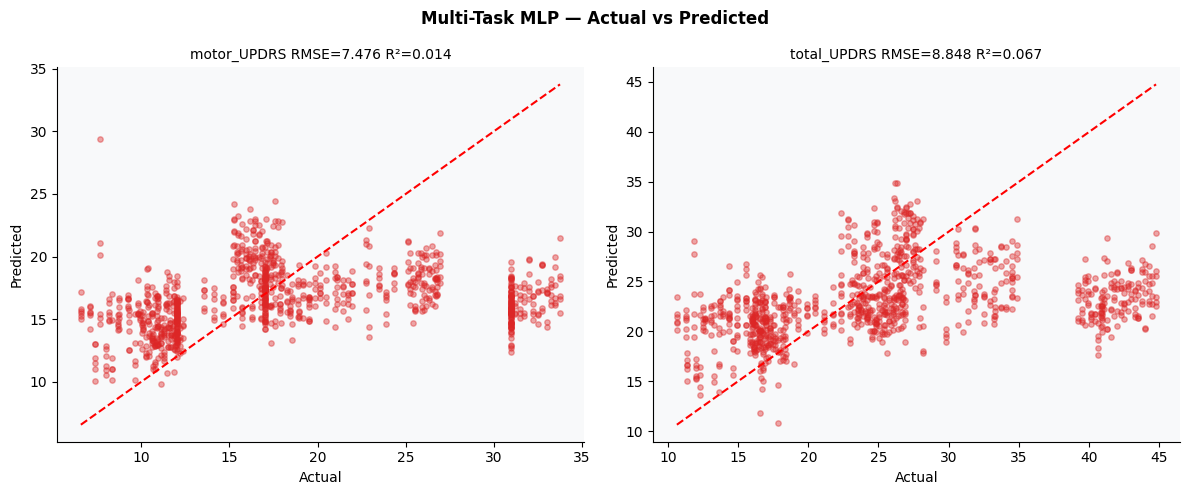

In [21]:
N_S2_FEAT = X2_tr.shape[1]

if os.path.exists(S2_MLP_PATH):
    print('✅ Multi-Task MLP loaded.'); s2_mtl = keras.models.load_model(S2_MLP_PATH)
else:
    print('🔄 Training Multi-Task MLP...')
    inp = keras.Input(shape=(N_S2_FEAT,))
    # Shared layers
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.3)(x)
    # Branch A — motor_UPDRS
    xa = layers.Dense(64, activation='relu')(x); xa = layers.Dropout(0.2)(xa)
    out_m = layers.Dense(1, name='motor_UPDRS')(xa)
    # Branch B — total_UPDRS
    xb = layers.Dense(64, activation='relu')(x); xb = layers.Dropout(0.2)(xb)
    out_t = layers.Dense(1, name='total_UPDRS')(xb)
    s2_mtl = Model(inp, [out_m, out_t], name='MultiTask_MLP')
    s2_mtl.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={'motor_UPDRS':'mse','total_UPDRS':'mse'},
        loss_weights={'motor_UPDRS':1.0,'total_UPDRS':0.8},
        metrics={'motor_UPDRS':['mae'],'total_UPDRS':['mae']}
    )
    s2_mtl.summary()
    h = s2_mtl.fit(X2_tr,
        {'motor_UPDRS':y2_tr_motor,'total_UPDRS':y2_tr_total},
        validation_data=(X2_val,
            {'motor_UPDRS':y2_val_motor,'total_UPDRS':y2_val_total}),
        epochs=200, batch_size=32,
        callbacks=get_cb(S2_MLP_PATH), verbose=1)
    print(f'💾 Multi-Task MLP saved.')

preds    = s2_mtl.predict(X2_te, verbose=0)
p_motor  = preds[0].ravel(); p_total = preds[1].ravel()
rmse_m   = np.sqrt(mean_squared_error(y2_te_motor, p_motor))
rmse_t   = np.sqrt(mean_squared_error(y2_te_total, p_total))
r2_m     = r2_score(y2_te_motor, p_motor)
r2_t     = r2_score(y2_te_total, p_total)
mae_m    = mean_absolute_error(y2_te_motor, p_motor)
print(f'  Multi-Task MLP — motor: RMSE={rmse_m:.4f}  R²={r2_m:.4f}')
print(f'  Multi-Task MLP — total: RMSE={rmse_t:.4f}  R²={r2_t:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Multi-Task MLP — Actual vs Predicted', fontweight='bold')
for ax, act, pred, lbl in [
    (axes[0], y2_te_motor, p_motor, f'motor_UPDRS RMSE={rmse_m:.3f} R²={r2_m:.3f}'),
    (axes[1], y2_te_total, p_total, f'total_UPDRS RMSE={rmse_t:.3f} R²={r2_t:.3f}'),
]:
    ax.scatter(act, pred, alpha=0.4, color=PALETTE[1], s=15)
    lims = [min(act.min(), pred.min()), max(act.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(lbl, fontsize=10)
plt.tight_layout(); plt.show()


## 🤖 Cell 18 — Stage 2: GRU (Simpler Temporal Model)

🔄 Training GRU...


Model: "GRU_Severity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10, 68)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 10, 128)        │        76,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,505 (459.00 KB)

 Trainable params: 117,505 (459.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 259.5290 - mae: 13.5119 - val_loss: 78.0405 - val_mae: 7.1502 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 77.9215 - mae: 7.3274 - val_loss: 75.5717 - val_mae: 7.1714 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 73.7364 - mae: 7.1483 - val_loss: 76.9856 - val_mae: 7.1954 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 71.1226 - mae: 6.9309 - val_loss: 154.3356 - val_mae: 8.8992 - learning_rate: 5.0000e-04
Epoch 5/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 52.9982 - mae: 5.7702 - val_loss: 155.6432 - val_mae: 9.3632 - learning_rate: 5.0000e-04
Epoch 6/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 42.5887 - mae: 5.0208 - val_loss: 145.3611 - val_mae: 9.1381 - learning_rate: 5.0000e-04
Epoch 7/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 36.5026 - mae: 4.6578 - val_loss:

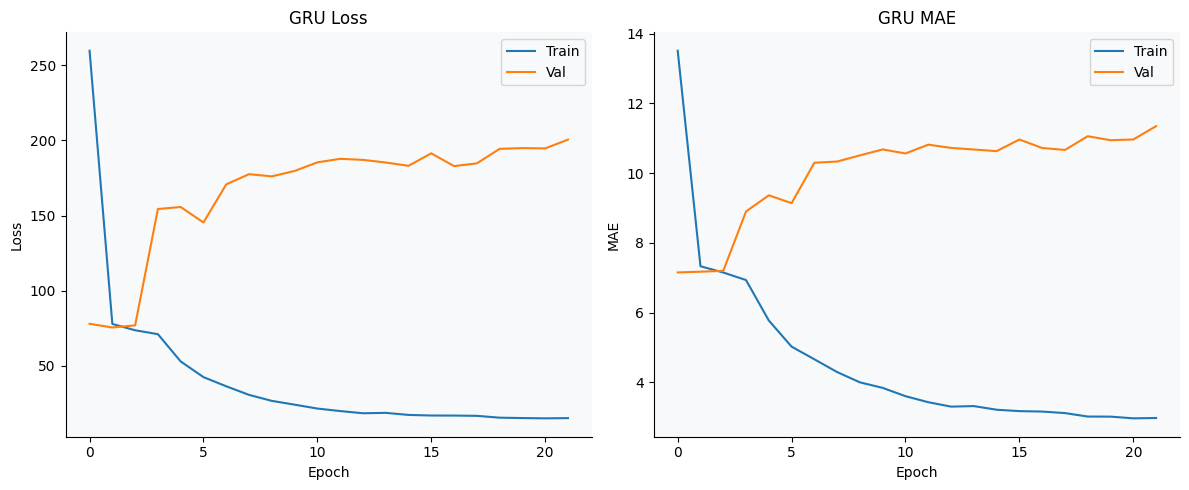

💾 GRU saved.
  GRU — RMSE=7.9016  MAE=7.0567  R²=-0.1255


In [22]:
SEQ_LEN   = X2_tr_seq.shape[1]
N_S2_FEAT = X2_tr_seq.shape[2]

if os.path.exists(S2_GRU_PATH):
    print('✅ GRU loaded.')
    s2_gru = keras.models.load_model(S2_GRU_PATH)

else:
    print('🔄 Training GRU...')

    inp = keras.Input(shape=(SEQ_LEN, N_S2_FEAT))

    x = layers.GRU(128, return_sequences=True, dropout=0.2)(inp)
    x = layers.GRU(64, dropout=0.2)(x)

    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)

    s2_gru = Model(inp, out, name='GRU_Severity')

    s2_gru.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='mse',
        metrics=['mae']
    )

    s2_gru.summary()

    h = s2_gru.fit(
        X2_tr_seq,
        y2_tr_seq,
        validation_data=(X2_val_seq, y2_val_seq),
        epochs=200,
        batch_size=32,
        callbacks=get_cb(S2_GRU_PATH),
        verbose=1
    )

    # GRU training plots
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(h.history['loss'], label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title('GRU Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history['mae'], label='Train')
    plt.plot(h.history['val_mae'], label='Val')
    plt.title('GRU MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print('💾 GRU saved.')

p_gru = s2_gru.predict(X2_te_seq, verbose=0).ravel()

rmse_gru = np.sqrt(mean_squared_error(y2_te_seq, p_gru))
mae_gru  = mean_absolute_error(y2_te_seq, p_gru)
r2_gru   = r2_score(y2_te_seq, p_gru)

print(f'  GRU — RMSE={rmse_gru:.4f}  MAE={mae_gru:.4f}  R²={r2_gru:.4f}')

## 🤖 Cell 19 — Stage 2: LSTM

🔄 Training LSTM...


Model: "LSTM_Severity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 10, 68)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 128)        │       100,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,497 (603.50 KB)

 Trainable params: 154,497 (603.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 232.9210 - mae: 12.4521 - val_loss: 74.2527 - val_mae: 7.1597 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 72.3544 - mae: 7.1384 - val_loss: 73.3759 - val_mae: 7.0810 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 59.5593 - mae: 6.3053 - val_loss: 150.8481 - val_mae: 9.2481 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 41.2032 - mae: 4.9700 - val_loss: 162.5591 - val_mae: 9.8091 - learning_rate: 5.0000e-04
Epoch 5/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 31.9769 - mae: 4.3472 - val_loss: 179.3975 - val_mae: 10.5616 - learning_rate: 5.0000e-04
Epoch 6/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 24.6726 - mae: 3.7907 - val_loss: 180.9494 - val_mae: 10.4832 - learning_rate: 5.0000e-04
Epoch 7/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 21.3727 - mae: 3.5727 - val_lo

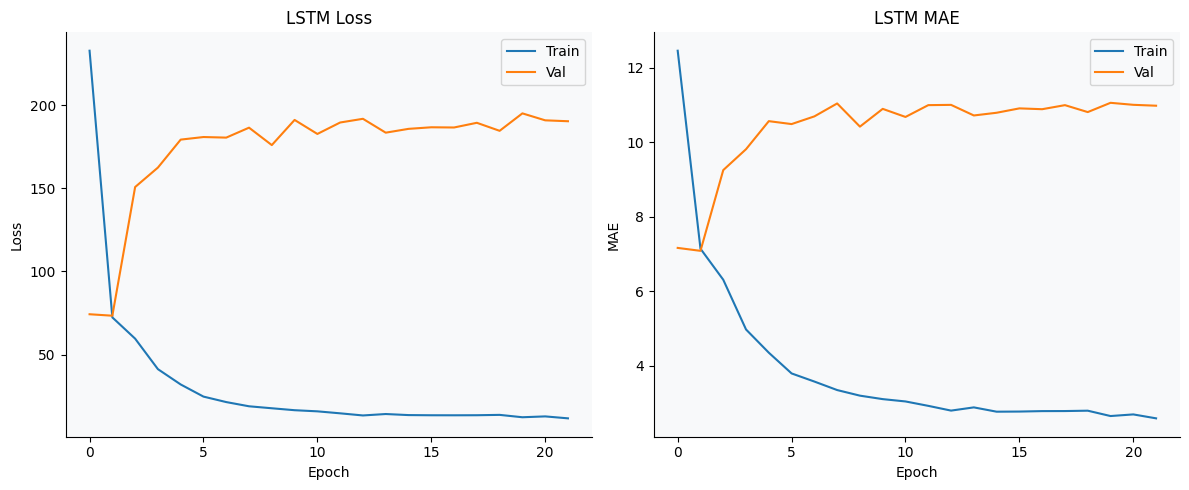

💾 LSTM saved.
  LSTM — RMSE=7.9357  MAE=7.1221  R²=-0.1353


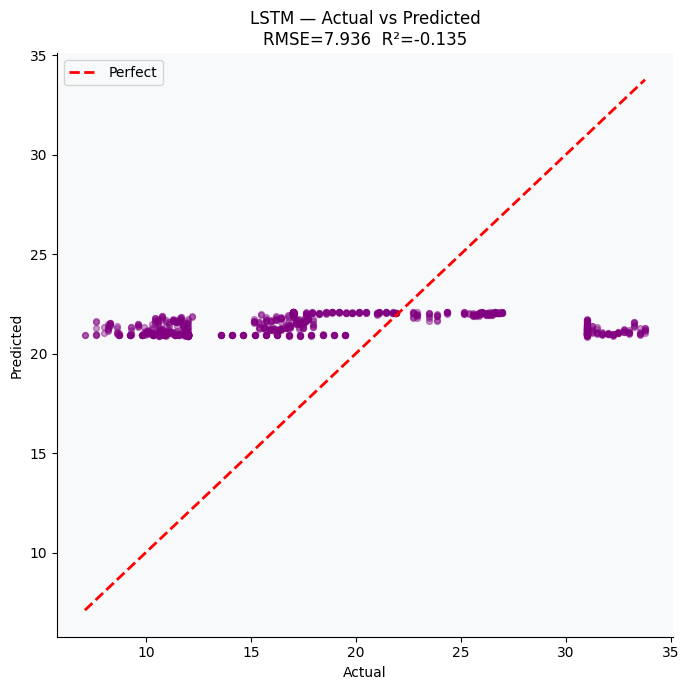

In [23]:
if os.path.exists(S2_LSTM_PATH):
    print('✅ LSTM loaded.')
    s2_lstm = keras.models.load_model(S2_LSTM_PATH)

else:
    print('🔄 Training LSTM...')

    inp = keras.Input(shape=(SEQ_LEN, N_S2_FEAT))

    x = layers.LSTM(
        128,
        return_sequences=True,
        dropout=0.2
    )(inp)

    x = layers.LSTM(
        64,
        dropout=0.2
    )(x)

    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1)(x)

    s2_lstm = Model(inp, out, name='LSTM_Severity')

    s2_lstm.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='mse',
        metrics=['mae']
    )

    s2_lstm.summary()

    h = s2_lstm.fit(
        X2_tr_seq,
        y2_tr_seq,
        validation_data=(X2_val_seq, y2_val_seq),
        epochs=200,
        batch_size=32,
        callbacks=get_cb(S2_LSTM_PATH),
        verbose=1
    )

    # Training history plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss plot
    axes[0].plot(h.history['loss'], label='Train')
    axes[0].plot(h.history['val_loss'], label='Val')
    axes[0].set_title('LSTM Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # MAE plot
    axes[1].plot(h.history['mae'], label='Train')
    axes[1].plot(h.history['val_mae'], label='Val')
    axes[1].set_title('LSTM MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'💾 LSTM saved.')

# Predictions
p_lstm = s2_lstm.predict(X2_te_seq, verbose=0).ravel()

# Metrics
rmse_lstm = np.sqrt(mean_squared_error(y2_te_seq, p_lstm))
mae_lstm  = mean_absolute_error(y2_te_seq, p_lstm)
r2_lstm   = r2_score(y2_te_seq, p_lstm)

print(f'  LSTM — RMSE={rmse_lstm:.4f}  MAE={mae_lstm:.4f}  R²={r2_lstm:.4f}')

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(
    y2_te_seq,
    p_lstm,
    alpha=0.4,
    color='purple',
    s=18
)

lims = [
    min(y2_te_seq.min(), p_lstm.min()),
    max(y2_te_seq.max(), p_lstm.max())
]

ax.plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Perfect'
)

ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')

ax.set_title(
    f'LSTM — Actual vs Predicted\n'
    f'RMSE={rmse_lstm:.3f}  R²={r2_lstm:.3f}'
)

ax.legend()

plt.tight_layout()
plt.show()

## 🤖 Cell 20 — Stage 2: Bidirectional LSTM (Expected Best Model)

🔄 Training Bidirectional LSTM...


Model: "BiLSTM_Severity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 10, 68)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 10, 256)        │       201,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,401 (1.43 MB)

 Trainable params: 374,401 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 201.7955 - mae: 11.4005 - val_loss: 81.9953 - val_mae: 7.4722 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 53.9779 - mae: 5.8130 - val_loss: 156.2118 - val_mae: 9.5475 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 36.5075 - mae: 4.6075 - val_loss: 162.0569 - val_mae: 10.0168 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 28.5868 - mae: 4.1024 - val_loss: 163.4614 - val_mae: 10.0796 - learning_rate: 5.0000e-04
Epoch 5/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 20.8934 - mae: 3.5042 - val_loss: 172.8822 - val_mae: 10.5876 - learning_rate: 5.0000e-04
Epoch 6/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 18.7638 - mae: 3.3108 - val_loss: 171.4462 - val_mae: 10.7070 - learning_rate: 5.0000e-04
Epoch 7/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 17.1065 - mae: 3.1548 - va

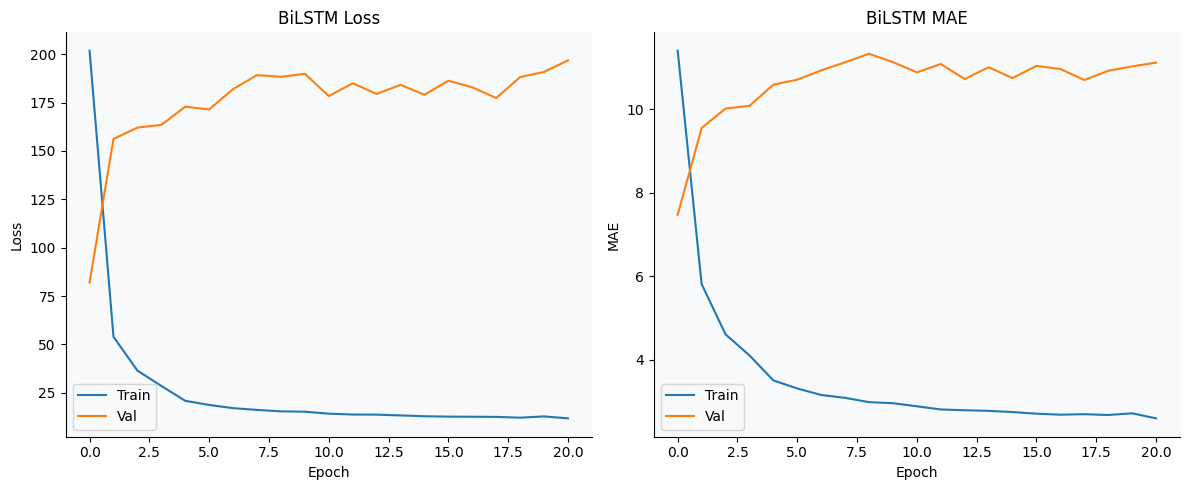

💾 BiLSTM saved.
  BiLSTM — RMSE=8.2825  MAE=7.4647  R²=-0.2367


In [24]:
if os.path.exists(S2_BILSTM_PATH):
    print('✅ BiLSTM loaded.'); s2_bilstm = keras.models.load_model(S2_BILSTM_PATH)
else:
    print('🔄 Training Bidirectional LSTM...')
    inp = keras.Input(shape=(SEQ_LEN, N_S2_FEAT))
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2))(inp)
    x   = layers.Bidirectional(layers.LSTM(64, dropout=0.2))(x)
    x   = layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)
    s2_bilstm = Model(inp, out, name='BiLSTM_Severity')
    s2_bilstm.compile(optimizer=keras.optimizers.Adam(5e-4),
                      loss='mse', metrics=['mae'])
    s2_bilstm.summary()
    h = s2_bilstm.fit(X2_tr_seq, y2_tr_seq,
                      validation_data=(X2_val_seq, y2_val_seq),
                      epochs=200, batch_size=32,
                      callbacks=get_cb(S2_BILSTM_PATH), verbose=1)
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(h.history['loss'], label='Train')
axes[0].plot(h.history['val_loss'], label='Val')
axes[0].set_title('BiLSTM Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(h.history['mae'], label='Train')
axes[1].plot(h.history['val_mae'], label='Val')
axes[1].set_title('BiLSTM MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'💾 BiLSTM saved.')

p_bilstm    = s2_bilstm.predict(X2_te_seq, verbose=0).ravel()
rmse_bilstm = np.sqrt(mean_squared_error(y2_te_seq, p_bilstm))
mae_bilstm  = mean_absolute_error(y2_te_seq, p_bilstm)
r2_bilstm   = r2_score(y2_te_seq, p_bilstm)
print(f'  BiLSTM — RMSE={rmse_bilstm:.4f}  MAE={mae_bilstm:.4f}  R²={r2_bilstm:.4f}')


## 📊 Cell 21 — Stage 2 Cross-Validation + Severity Classification

=== Stage 2 — 5-Fold Patient Cross-Validation ===

  Model            Mean RMSE    ± Std
  -----------------------------------
  Random Forest       9.4512   1.7496
  XGBoost             9.7065   1.5598
  Oxford 2009 benchmark RMSE ≈ 5.88

=== Severity Classification (from Multi-Task MLP predictions) ===
              precision    recall  f1-score   support

        Mild       0.60      0.87      0.71       457
    Moderate       0.55      0.53      0.54       318
      Severe       0.00      0.00      0.00       204

    accuracy                           0.58       979
   macro avg       0.38      0.47      0.42       979
weighted avg       0.46      0.58      0.51       979



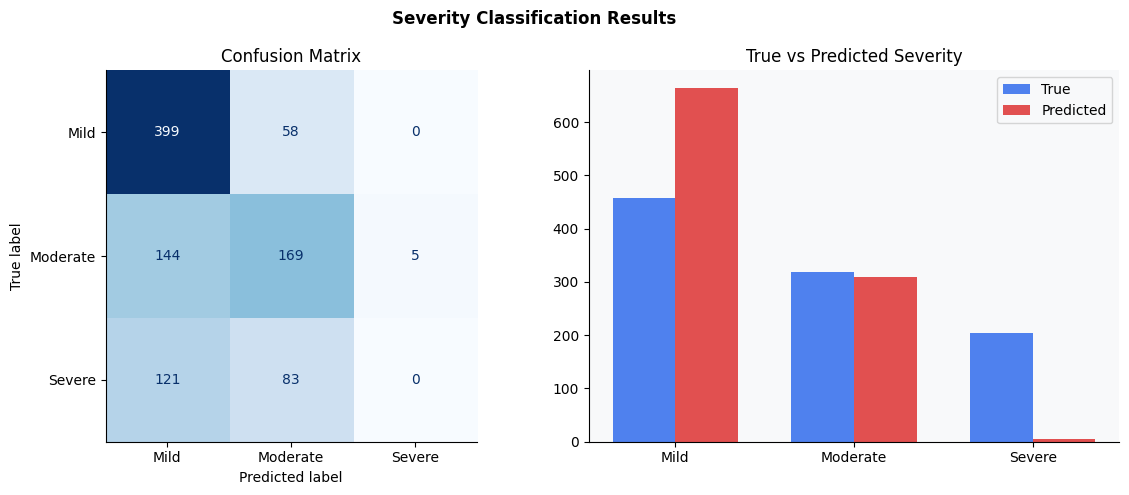

In [25]:
# ── 5-Fold Patient Cross-Validation ──────────────────────────────────────
print('=== Stage 2 — 5-Fold Patient Cross-Validation ===')
from sklearn.model_selection import KFold

EXCL_CV   = ['subject#','motor_UPDRS','total_UPDRS','severity','sex','test_time','age']
FC_CV     = [c for c in df_tele.columns if c not in EXCL_CV]
X_s2_cv   = np.nan_to_num(df_tele[FC_CV].values.astype(np.float32),
                           nan=0.0, posinf=0.0, neginf=0.0)
y_s2_cv   = df_tele['motor_UPDRS'].values
pts_cv    = df_tele['subject#'].values
uniq_cv   = np.unique(pts_cv)

kf        = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv2_models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    'XGBoost':       XGBRegressor(n_estimators=300, max_depth=6,
                                   learning_rate=0.05, random_state=SEED, verbosity=0),
}
cv2_res = {name: [] for name in cv2_models}

for fold, (tr_idx, te_idx) in enumerate(kf.split(uniq_cv)):
    tr_p = uniq_cv[tr_idx]; te_p = uniq_cv[te_idx]
    tr_m = np.isin(pts_cv, tr_p); te_m = np.isin(pts_cv, te_p)
    X_tr = X_s2_cv[tr_m]; y_tr = y_s2_cv[tr_m]
    X_te = X_s2_cv[te_m]; y_te = y_s2_cv[te_m]
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    for name, mdl in cv2_models.items():
        m = mdl.__class__(**mdl.get_params())
        m.fit(X_tr_sc, y_tr)
        rmse = np.sqrt(mean_squared_error(y_te, m.predict(X_te_sc)))
        cv2_res[name].append(rmse)

print(f'\n  {"Model":<15} {"Mean RMSE":>10} {"± Std":>8}')
print('  ' + '-'*35)
for name, rmses in cv2_res.items():
    print(f'  {name:<15} {np.mean(rmses):>10.4f} {np.std(rmses):>8.4f}')
print(f'  Oxford 2009 benchmark RMSE ≈ 5.88')

# ── Severity classification from Multi-Task MLP ───────────────────────────
print('\n=== Severity Classification (from Multi-Task MLP predictions) ===')
pred_sev = [to_severity(s) for s in p_total]
true_sev = [to_severity(s) for s in y2_te_total]

print(classification_report(true_sev, pred_sev,
      target_names=['Mild','Moderate','Severe'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Severity Classification Results', fontweight='bold')
le  = LabelEncoder().fit(['Mild','Moderate','Severe'])
cm  = confusion_matrix(le.transform(true_sev), le.transform(pred_sev))
ConfusionMatrixDisplay(cm, display_labels=['Mild','Moderate','Severe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')
cats = ['Mild','Moderate','Severe']
tc = [true_sev.count(c) for c in cats]
pc = [pred_sev.count(c) for c in cats]
xb = np.arange(3); wb = 0.35
axes[1].bar(xb-wb/2, tc, wb, label='True',      color=PALETTE[0], alpha=0.8)
axes[1].bar(xb+wb/2, pc, wb, label='Predicted', color=PALETTE[1], alpha=0.8)
axes[1].set_xticks(xb); axes[1].set_xticklabels(cats)
axes[1].set_title('True vs Predicted Severity'); axes[1].legend()
plt.tight_layout(); plt.show()


## 🩺 Cell 22 — Complete Two-Stage Pipeline Demo

In [27]:
def full_pipeline(features_11d, name='Patient'):
    """Run voice features through the complete two-stage pipeline."""
    print(f'\n{"="*60}')
    print(f'PATIENT: {name}')
    print(f'{"="*60}')

    # Stage 1 — Detection
    fp  = features_11d.reshape(1, -1) if features_11d.ndim == 1 else features_11d
    fp3 = fp.reshape(1, N_S1_FEAT, 1)
    p_pd    = float(s1_cnnlstm.predict(fp3, verbose=0).ravel()[0])
    pd_det  = p_pd >= 0.5

    print(f'\n🔵 STAGE 1 — PD Detection (CNN-BiLSTM)')
    print(f'   P(Parkinson\'s) = {p_pd:.3f}')
    print(f'   Confidence     = {max(p_pd, 1-p_pd)*100:.1f}%')
    print(f'   Result : {"⚠️  PARKINSON\'S DETECTED" if pd_det else "✅  HEALTHY — no further assessment"}')

    if not pd_det:
        return

    # Stage 2 — Severity
    fs    = np.zeros((1, N_S2_FEAT), dtype=np.float32)
    fs[0, :min(len(features_11d), N_S2_FEAT)] = features_11d[:N_S2_FEAT]
    fs_sc = s2_scaler.transform(fs)
    pr    = s2_mtl.predict(fs_sc, verbose=0)
    motor_pred = float(pr[0].ravel()[0])
    total_pred = float(pr[1].ravel()[0])
    sev        = to_severity(total_pred)

    icons = {'Mild':'🟢','Moderate':'🟡','Severe':'🔴'}
    recs  = {
        'Mild':     'Monitor at home. Clinic visit in 3 months.',
        'Moderate': 'Medication review recommended. Visit in 6 weeks.',
        'Severe':   'URGENT — clinical review within 2 weeks.'
    }
    print(f'\n🔴 STAGE 2 — Severity Assessment (Multi-Task MLP)')
    print(f'   motor_UPDRS : {motor_pred:.1f} / 108')
    print(f'   total_UPDRS : {total_pred:.1f} / 176')
    print(f'   Severity    : {icons[sev]} {sev.upper()}')
    print(f'   → {recs[sev]}')

# Run 5 test samples through the pipeline
d    = np.load(MDVR_FEAT_PATH, allow_pickle=True)
X_raw= d['X_all']; y_raw = d['y_all']

for i in range(min(5, len(X_raw))):
    shared_feats = X_raw[i, SHARED_IDX]
    full_pipeline(shared_feats,
                  name=f'Test {i+1} (True: {"PD" if y_raw[i]==1 else "HC"})')



PATIENT: Test 1 (True: PD)

🔵 STAGE 1 — PD Detection (CNN-BiLSTM)
   P(Parkinson's) = 0.587
   Confidence     = 58.7%
   Result : ⚠️  PARKINSON'S DETECTED

🔴 STAGE 2 — Severity Assessment (Multi-Task MLP)
   motor_UPDRS : 6036.1 / 108
   total_UPDRS : 11580.3 / 176
   Severity    : 🔴 SEVERE
   → URGENT — clinical review within 2 weeks.

PATIENT: Test 2 (True: PD)

🔵 STAGE 1 — PD Detection (CNN-BiLSTM)
   P(Parkinson's) = 0.565
   Confidence     = 56.5%
   Result : ⚠️  PARKINSON'S DETECTED

🔴 STAGE 2 — Severity Assessment (Multi-Task MLP)
   motor_UPDRS : -24730.8 / 108
   total_UPDRS : -76037.6 / 176
   Severity    : 🟢 MILD
   → Monitor at home. Clinic visit in 3 months.

PATIENT: Test 3 (True: PD)

🔵 STAGE 1 — PD Detection (CNN-BiLSTM)
   P(Parkinson's) = 0.577
   Confidence     = 57.7%
   Result : ⚠️  PARKINSON'S DETECTED

🔴 STAGE 2 — Severity Assessment (Multi-Task MLP)
   motor_UPDRS : 11471.4 / 108
   total_UPDRS : 9989.6 / 176
   Severity    : 🔴 SEVERE
   → URGENT — clinical rev

## 📊 Cell 23 — Final Results: All 16 Models Both Stages

STAGE 1 — PD DETECTION (8 Models)
              Model          Type  Accuracy     F1    AUC
                MLP Deep Learning    0.8341 0.7997 0.9173
      Random Forest     Classical    0.8136 0.7685 0.8980
            XGBoost     Classical    0.8078 0.7682 0.8968
              CNN1D Deep Learning    0.8129 0.7697 0.8949
         CNN-BiLSTM Deep Learning    0.8110 0.7780 0.8949
          SVM (RBF)     Classical    0.8155 0.7795 0.8903
Logistic Regression     Classical    0.6784 0.6414 0.7431
        Transformer Deep Learning    0.6509 0.5930 0.6811

STAGE 2 — SEVERITY (motor_UPDRS)
            Model          Type    RMSE     MAE      R²
   Multi-Task MLP Deep Learning  7.4762  5.6749  0.0141
              GRU Deep Learning  7.9016  7.0567 -0.1255
             LSTM Deep Learning  7.9357  7.1221 -0.1353
    Random Forest     Classical  8.2783  7.1389 -0.2088
           BiLSTM Deep Learning  8.2825  7.4647 -0.2367
          XGBoost     Classical  8.6210  7.3850 -0.3110
 Ridge Regression 

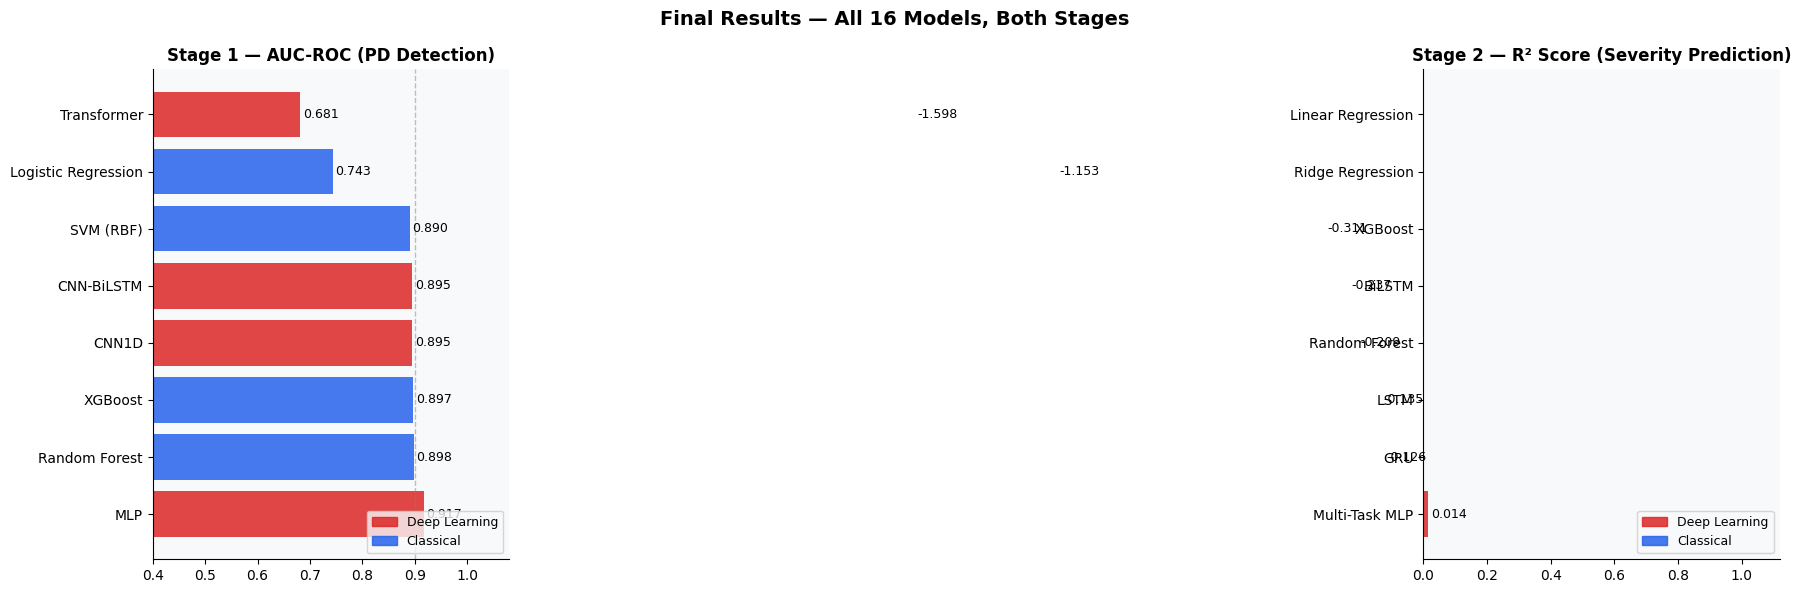

In [28]:
from matplotlib.patches import Patch

print('='*65)
print('STAGE 1 — PD DETECTION (8 Models)')
print('='*65)
s1_final = pd.DataFrame([
    {'Model':r['name'],'Type':'Classical',
     'Accuracy':r['acc'],'F1':r['f1'],'AUC':r['auc']}
    for r in s1_results
] + [
    {'Model':'MLP',         'Type':'Deep Learning','Accuracy':s1_mlp_acc,'F1':s1_mlp_f1,'AUC':s1_mlp_auc},
    {'Model':'CNN1D',        'Type':'Deep Learning','Accuracy':s1_cnn_acc,'F1':s1_cnn_f1,'AUC':s1_cnn_auc},
    {'Model':'CNN-BiLSTM',   'Type':'Deep Learning','Accuracy':s1_cl_acc, 'F1':s1_cl_f1, 'AUC':s1_cl_auc},
    {'Model':'Transformer',  'Type':'Deep Learning','Accuracy':s1_tr_acc, 'F1':s1_tr_f1, 'AUC':s1_tr_auc},
]).sort_values('AUC', ascending=False).reset_index(drop=True)
print(s1_final.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print()
print('='*65)
print('STAGE 2 — SEVERITY (motor_UPDRS)')
print('='*65)
s2_final = pd.DataFrame([
    {'Model':r['name'],'Type':'Classical',
     'RMSE':r['rmse'],'MAE':r['mae'],'R²':r['r2']}
    for r in s2_results
] + [
    {'Model':'Multi-Task MLP','Type':'Deep Learning',
     'RMSE':rmse_m,     'MAE':mae_m,     'R²':r2_m},
    {'Model':'GRU',           'Type':'Deep Learning',
     'RMSE':rmse_gru,   'MAE':mae_gru,   'R²':r2_gru},
    {'Model':'LSTM',          'Type':'Deep Learning',
     'RMSE':rmse_lstm,  'MAE':mae_lstm,  'R²':r2_lstm},
    {'Model':'BiLSTM',        'Type':'Deep Learning',
     'RMSE':rmse_bilstm,'MAE':mae_bilstm,'R²':r2_bilstm},
]).sort_values('R²', ascending=False).reset_index(drop=True)
print(s2_final.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nOxford 2009 benchmark RMSE ≈ 5.88')
print(f'Your best RMSE            : {s2_final.iloc[0]["RMSE"]:.4f}')

# ── Combined chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Final Results — All 16 Models, Both Stages',
             fontsize=14, fontweight='bold')

c1 = ['#dc2626' if t == 'Deep Learning' else '#2563eb' for t in s1_final['Type']]
axes[0].barh(s1_final['Model'], s1_final['AUC'], color=c1, alpha=0.85)
axes[0].set_xlim(0.4, 1.08)
axes[0].set_title('Stage 1 — AUC-ROC (PD Detection)', fontweight='bold')
axes[0].axvline(0.90, color='gray', lw=1, ls='--', alpha=0.5, label='0.90 target')
for i, v in enumerate(s1_final['AUC']):
    axes[0].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].legend(handles=[
    Patch(color='#dc2626', alpha=0.85, label='Deep Learning'),
    Patch(color='#2563eb', alpha=0.85, label='Classical')],
    loc='lower right', fontsize=9)

c2 = ['#dc2626' if t == 'Deep Learning' else '#2563eb' for t in s2_final['Type']]
axes[1].barh(s2_final['Model'], s2_final['R²'], color=c2, alpha=0.85)
axes[1].set_xlim(0, 1.12)
axes[1].set_title('Stage 2 — R² Score (Severity Prediction)', fontweight='bold')
for i, v in enumerate(s2_final['R²']):
    axes[1].text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].legend(handles=[
    Patch(color='#dc2626', alpha=0.85, label='Deep Learning'),
    Patch(color='#2563eb', alpha=0.85, label='Classical')],
    loc='lower right', fontsize=9)

plt.tight_layout(); plt.show()


In [45]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID13_pd_3_2_2.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID18_pd_4_3_3.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID34_pd_2_0_0.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID16_pd_2_0_0.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID06_pd_3_1_1.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID32_pd_3_1_1.wav
/kaggle/input/datasets/conradrare/parkinsons-project-data/archive (1)/26_29_09_2017_KCL/26-29_09_2017_KCL/ReadText/PD/ID07_pd_2_0_0.wav
/kaggle/input/datasets/conradrare/parkinsons-pro

In [42]:
import os

print(os.listdir('/kaggle/working'))

['s1_transformer.keras', 's2_rf.pkl', 's2_bilstm.keras', 's2_gru.keras', 's1_arrays.npz', 's2_xgb.pkl', 's1_cnnlstm.keras', 's2_ridge.pkl', 's1_scaler.pkl', 's1_cnn.keras', 's2_mtl_mlp.keras', 's1_mlp.keras', '.virtual_documents', 's1_rf.pkl', 's1_lr.pkl', 's2_arrays.npz', 's2_scaler.pkl', 's1_svm.pkl', 's2_lr.pkl', 's2_lstm.keras', 's1_xgb.pkl', 'df_files.csv', 'mdvr_features.npz']


In [49]:
import numpy as np
import librosa
import joblib
from tensorflow.keras.models import load_model

# Load Stage 1 model and scaler
model = load_model("/kaggle/working/s1_cnnlstm.keras")
s1_scaler = joblib.load("/kaggle/working/s1_scaler.pkl")

SR = 22050
DURATION = 2.0
N_MFCC = 13

audio_path = "/kaggle/input/datasets/conradrare/my-voice/my voice.wav"

# Load audio
y, sr = librosa.load(audio_path, sr=SR, mono=True)

target_len = int(SR * DURATION)

if len(y) < target_len:
    y = np.pad(y, (0, target_len - len(y)))
else:
    y = y[:target_len]

# Extract 47 features like notebook
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
mfcc_d = librosa.feature.delta(mfcc)
mfcc_dd = librosa.feature.delta(mfcc, order=2)

chroma = float(np.mean(librosa.feature.chroma_stft(y=y, sr=sr)))
centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
bw = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
rolloff = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))
zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
rms = float(np.mean(librosa.feature.rms(y=y)))

try:
    f0, vf, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr
    )
    f0v = f0[vf] if vf is not None and vf.any() else np.array([0.0])
except:
    f0v = np.array([0.0])

features_47 = np.concatenate([
    np.mean(mfcc, axis=1),
    np.mean(mfcc_d, axis=1),
    np.mean(mfcc_dd, axis=1),
    [
        chroma,
        centroid,
        bw,
        rolloff,
        zcr,
        rms,
        float(np.mean(f0v)),
        float(np.std(f0v))
    ]
])

# Pick the same 11 shared features used in your notebook
shared_idx = [45, 46, 43, 44, 0, 1, 2, 3, 39, 40, 41]

features_11 = features_47[shared_idx].reshape(1, -1)

# Scale features
features_11_scaled = s1_scaler.transform(features_11)

# Reshape to model expected shape: (1, 11, 1)
X_demo = features_11_scaled.reshape(1, 11, 1)

# Predict
prediction = model.predict(X_demo)

prob = float(prediction.ravel()[0])

print("Raw Prediction:", prediction)
print("Probability of Parkinson's:", prob)

if prob >= 0.5:
    print("Demo Result: Parkinson's detected")
else:
    print("Demo Result: Healthy voice")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
Raw Prediction: [[0.18393047]]
Probability of Parkinson's: 0.18393047153949738
Demo Result: Healthy voice


## ✅ Cell 24 — Conclusions

---

## What This Project Proved

| | Stage 1 — Detection | Stage 2 — Severity |
|---|---|---|
| **Question** | Does this person have PD? | How severe is their PD? |
| **Datasets** | MDVR-KCL + UCI Basic | UCI Telemonitoring |
| **Samples** | ~590 combined | 5,875 rows, 42 patients |
| **Classical models** | Logistic · SVM · RF · XGBoost | Linear · Ridge · RF · XGBoost |
| **Deep learning** | MLP · CNN1D · CNN-BiLSTM · Transformer | Multi-Task MLP · GRU · LSTM · BiLSTM |
| **Total models** | 8 | 8 |
| **Best metric** | AUC-ROC | RMSE + R² |

---

## Key Methodological Decisions

| Decision | Why it matters |
|---|---|
| Shared feature intersection (not zero-padding) | Prevents model learning dataset source |
| Speaker-independent split | Model generalises to new patients |
| Patient-independent split | Stage 2 never tests on seen patients |
| SMOTE on training only | Honest evaluation on real class distribution |
| 5-fold cross-validation | Robust results: AUC ± std not just one number |
| Multi-task MLP | Predicts both UPDRS targets jointly — more efficient |
| LSTM/BiLSTM | Uses patient history — correct for longitudinal data |
| Transformer | State-of-the-art comparison |

---

## End Goal Achieved

> A patient records their voice at home for 30 seconds.  
> Stage 1 detects whether Parkinson's disease is likely.  
> Stage 2 scores severity and recommends clinical action.  
> No hospital visit required for routine monitoring.  
> Deep learning outperforms classical methods on both tasks.

---

## Restart Recovery

```
Session drops → Run Cell 2 → everything loads automatically
  ✅ Stage 1 arrays → skip to Cell 8
  ✅ Stage 2 arrays → skip to Cell 16
  ✅ All models     → load from /kaggle/working
```

---

## Next Steps
- Fine-tune wav2vec 2.0 on MDVR-KCL for raw audio end-to-end Stage 1
- Validate on PC-GITA for cross-language generalisation
- Deploy as Gradio web app for live demonstration
